# **Problema de Navegación Logística Estocástica con Restricción de Combustible**
#  **Barco Pirata. Aprendizaje por Refuerzo**

#### **Autores: Brian Bedoya Piedrahita, Daniel Moraleda Sánchez y David Santiago Ruiz**

---

### **Descripción del problema**

Un agente controla un barco pirata en un mapa de **8x10 celdas** con mar abierto, islas, dos tipos de tormenta, corrientes marinas, un maelstrom (remolino de agua) y un puerto base. El objetivo es recoger los cuatro cofres del mapa, cada uno con distinto valor, y regresar al puerto antes de agotar las provisiones, adaptando la ruta a la dirección cambiante del viento.

Por qué este problema es complejo para RL:

- **Viento variable en el estado**: el agente conoce la dirección actual del viento y aprende a adaptar su ruta: aprovechar viento de cola, evitar rutas en contra. La misma acción tiene distinta distribución de transición según el viento, por lo que la dirección del viento forma parte del estado para preservar la propiedad de Markov.
- **4 cofres con valores distintos**: no todos los tesoros valen igual (+20, +35, +50, +70); la política óptima implica ponderar riesgo y recompensa: ¿merece la pena arriesgarse para x recompensa con estas provisiones y este tiempo?
- **Provisiones discretizadas en 4 niveles**: la política cambia cualitativamente entre niveles: con provisiones altas el agente puede explorar, con provisiones críticas debe ir directamente al puerto.
- **Corrientes marinas y maelstrom**: elementos deterministas del mapa que el agente aprende a explotar como atajos o evitar como trampas.
- **Dos tipos de tormenta**: riesgo gradual: tormenta moderada y tormenta severa con distintos niveles de desvío, forzando al agente a diferenciar zonas de riesgo.

---

## **2.1 Motivación del problema**

El Aprendizaje por Refuerzo destaca en problemas donde un agente debe tomar decisiones secuenciales bajo incertidumbre, aprendiendo de la interacción con el entorno sin conocimiento previo. El entorno del Barco Pirata captura esta naturaleza, combinando varias fuentes de complejidad simultáneas, como ya hemos explicado.

### **¿Por qué es interesante desde la perspectiva de la IA?**

**1. Navegación bajo incertidumbre**

El viento no solo es estocástico: su dirección cambia durante el episodio y forma parte del estado. El agente no aprende un camino fijo sino una política **π(s)** que decide de forma distinta según sople el viento: con viento de cola, la ruta directa puede compensar el riesgo de la tormenta severa; con viento en contra, esa misma ruta es imposible. Esto obliga al agente a "razonar" para tomar la decisión con mayor EV. Estamos simulando una serie temporal no estacionaria.

**2. Optimización combinatoria**

Con cuatro cofres de valores distintos (+20, +35, +50, +70) existen 4! = 24 órdenes posibles de recogida. A diferencia de problemas donde todos los objetivos tienen el mismo valor, aquí el agente debe ponderar riesgo y recompensa: el cofre legendario (+70) está rodeado de tormenta fuerte. La política óptima no puede calcularse de forma estática porque depende de la dirección actual del viento y el nivel de provisiones. Esto es un problema de optimización claro, no vale con un GPS con el algoritmo de Dijkstra.

**3. Gestión de recursos**

Las provisiones, discretizadas en cuatro niveles, introducen una restricción que cambia la política óptima. El mismo par (posición, cofres_recogidos) requiere decisiones completamente distintas dependiendo del nivel de provisiones. En el máximo el agente puede explorar rutas largas, en el mínimo debe ir directamente al puerto ignorando cofres cercanos.

**4. Explotación de elementos deterministas del mapa**

Las corrientes marinas desplazan el barco en una dirección fija. A diferencia de las tormentas, que siempre son un riesgo, las corrientes tienen las dos caras de la moneda: una corriente que lleva hacia el cofre es un atajo gratuito si el agente va en esa dirección, pero puede alejarlo si lo arrastra en dirección contraria. El agente debe aprender a explotar o evitar estos elementos según el contexto.

**5. Gestión de amenazas asimétricas**

El maelstrom atrapa al barco durante dos turnos consumiendo provisiones sin posibilidad de escapar. A diferencia de las tormentas (riesgo probabilístico), el maelstrom es una penalización determinista.

### **Aplicaciones en el mundo real**

Aunque el entorno es una simulación, el problema formalizado es análogo a escenarios de alta relevancia:

- **Robótica de exploración**: rovers planetarios (Mars Perseverance) que recogen muestras de distintas prioridades científica con batería limitada, adaptando la ruta a las condiciones variables del terreno.
- **Logística marítima**: buques que optimizan el orden de escalas de carga con restricciones de combustible, aprovechando corrientes marinas favorables y evitando zonas de mal tiempo.
- **Drones de reparto con prioridad variable**: vehículos autónomos que gestionan múltiples entregas de distinta urgencia con batería limitada en entornos con viento variable.

### **¿Por qué RL y no algoritmos clásicos?**

El algoritmo `A*` [Hart et al., 1968] garantiza el camino de coste mínimo en entornos **deterministas**, pero falla por dos razones en este entorno. Este razonamiento es análogo para `Dijkstra` o D\*. Primero, el viento estocástico invalida la planificación: el camino calculado como óptimo puede no ejecutarse tal como se proyectó. Segundo, la dirección del viento cambia durante el episodio, haciendo que el grafo de costes que A\* necesita sea no estacionario. El RL, al aprender directamente de la interacción, construye una política robusta que maximiza la recompensa esperada $\mathbb{E}[G_t]$ bajo cualquier realización del viento, sin asumir conocimiento previo de la dinámica de transición. 
No se cumplen las condiciones de entorno e invarianza temporal que requieren los algoritmos clásicos de búsqueda heurística en grafos.

---

## **2.2 Modelado del problema. Formalización MDP**

Un Proceso de Decisión de Markov (MDP) se define como la tupla $\mathcal{M} = (\mathcal{S}, \mathcal{A}, T, R, \gamma)$. A continuación se detalla y justifica cada componente para el entorno del Barco Pirata.

### **1. Espacio de Estados $\mathcal{S}$**

El estado en cada instante $t$ se define como:

$$s_t = (\text{fila}, \text{columna}, c_0, c_1, c_2, c_3, \text{nivel\_prov}, \text{dir\_viento})$$

| Variable | Tipo | Rango | Justificación |
|---|---|---|---|
| `fila` | Discreto | $[0, 7]$ | Posición vertical en el grid 8x10 |
| `columna` | Discreto | $[0, 9]$ | Posición horizontal en el grid 8x10 |
| $c_0, c_1, c_2, c_3$ | Binario | $\{0,1\}^4 = 16$ | Estado de cada cofre: 16 combinaciones |
| `nivel_prov` | Discreto | $\{0,1,2,3\}$ | Nivel cualitativo de provisiones |
| `dir_viento` | Discreto | $\{N,S,O,E\}$ | Dirección actual del viento |

**Discretización de provisiones en 4 niveles:**

$$\text{nivel\_prov}(p) = \begin{cases} 3 \text{ (ALTO)}    & p \geq 38 \\ 2 \text{ (MEDIO)}   & 26 \leq p < 38 \\ 1 \text{ (BAJO)}    & 13 \leq p < 26 \\ 0 \text{ (CRÍTICO)} & p < 13 \end{cases}$$

**Tamaño total del espacio de estados:**

$$|\mathcal{S}| = 8 \times 10 \times 2^4 \times 4 \times 4 = 20.480 \text{ estados}$$

Con 300.000 episodios de ~60 pasos cada uno se generan ~18.000.000 de transiciones. Esto podría hacernos pensar que cada par estado-acción será visitado una media de ~4 veces. Sin embargo esto es falso, ya que la distribución no es uniforme: El agente pasa el 90% del tiempo en las rutas óptimas o en las zonas intermedias del mapa. Estar en la esquina superior derecha, con provisiones en bajo nivel, habiendo recogido solo el cofre legendario y con viento un viento específico se visitarán 0 o 1 vez en todo el entrenamiento.

Aunque la distribución de visitas sobre el espacio de estados es asimétrica, un volumen de 18 millones de transiciones garantiza que los componentes del espacio de estados más relevantes para la trayectoria óptima converjan asintóticamente hacia sus valores Q reales.

> **Propiedad de Markov:** tanto `nivel_prov` como `dir_viento` son imprescindibles. Sin `nivel_prov`, el agente no puede distinguir situaciones que requieren políticas opuestas como ir a por el legendario con provisiones ALTAS vs ir directamente al puerto con provisiones CRÍTICAS. Sin `dir_viento`, la misma acción produce distribuciones de transición distintas según sople el viento, lo que no cumple la propiedad de Markov. Las corrientes y el maelstrom no forman parte del estado porque son celdas fijas del mapa. El agente aprende sus posiciones y efectos igual que aprende dónde están las islas.

### **2. Espacio de Acciones $\mathcal{A}$**

$$\mathcal{A} = \{\text{NORTE}, \text{SUR}, \text{OESTE}, \text{ESTE}\}$$

Cuatro acciones discretas de movimiento. No existe acción de recoger; el cofre se recoge automáticamente al pisar su celda (a diferencia , por ejemplo, del entorno Taxi de Gymnasium, donde hay acciones explícitas de recoger y dejar, aquí añadir una acción de recoger aumentaría innecesariamente la complejidad sin aportar valor estratégico, ya que siempre se desea recoger un cofre al alcanzarlo). No existe acción de esperar, sino que el *living penalty* hace que esperar sea siempre subóptimo. El maelstrom consume turnos automáticamente y no hay acción de escape.

### **Función de Recompensa $R(s, a, s')$**

Los cuatro cofres tienen valores distintos que reflejan su dificultad de acceso:

$$R(s, a, s') = \begin{cases} +v_i & \text{si se recoge el cofre } i \text{ en } s', \quad v \in \{20, 35, 50, 70\} \\ +100 + p × 1.5  & \text{si se llega al puerto con todos los cofres, donde p son las provisiones restantes} \\ -150 & \text{si las provisiones llegan a 0} \\ -6 & \text{por turno atrapado en el maelstrom (-1 living penalty + -5 adicional)} \\ -1 & \text{en cualquier otro caso (living penalty)} \end{cases}$$

**Justificación de cada término:**
- $-1$ por paso: evita rodeos y obliga al agente a ser eficiente con las provisiones.
- $v_i \in \{20, 35, 50, 70\}$: el valor de cada cofre refleja su riesgo de acceso: el legendario (+70) está rodeado de tormenta severa y solo es accesible con buenas provisiones y viento favorable.
- $+100 + p × 1.5$: el bonus proporcional a las provisiones restantes incentiva al agente a completar el episodio eficientemente, penalizando rodeos innecesarios incluso en la fase final.
- $-150$ agotamiento: penalización severa, ya que no queremos morir de hambre.
- $-6$ maelstrom: la living penalty se aplica en todo momento; el maelstrom añade -5 adicionales sobre ese -1 base, dando un coste total de -6 por turno inmovilizado.

**Verificación anti-reward hacking:**

| Estrategia | Recompensa total |
|---|---|
| Victoria óptima (~35 pasos) | 145 + 20 + 35 + 50 + 70 - 35 = +285  |
| Recoger solo legendario y morir | $70 - 10 - 150 = -90$  |
| Morir directamente | $-150$  peor caso |
| Quedarse atrapado en maelstrom hasta morir | $-6 \times 2 - 150 < -150$  |

### **3. Dinámica de Transición $T(s, a, s')$**

La transición es **estocástica y dependiente de la dirección del viento**. Las probabilidades de desvío dependen de la relación entre la acción elegida y la dirección actual del viento:

$$T(s' \mid s, a, \text{dir\_viento}) = \begin{cases} p_{\text{rel}} & \text{si } s' \text{ corresponde a la dirección elegida} \\ \frac{1-p_{\text{rel}}}{2} & \text{si } s' \text{ corresponde a cada perpendicular} \end{cases}$$

donde $p_{\text{rel}}$ depende de la relación movimiento-viento:

| Relación acción-viento | $p_{\text{dir}}$ | $p_{\perp}$ cada una |
|---|---|---|
| A favor (mismo sentido) | 0.80 | 0.10 |
| Perpendicular | 0.65 | 0.175 |
| En contra (sentido opuesto) | 0.50 | 0.25 |

En celdas de tormenta, $p_{\text{dir}}$ se reduce adicionalmente:

| Tipo de celda | Reducción de $p_{\text{dir}}$ |
|---|---|
| Tormenta moderada | $-0.15$ |
| Tormenta severa | $-0.25$ |

En celdas de tormenta, la reducción del potencial de avance ($\Delta p$) disminuye la probabilidad de la dirección elegida y se distribuye equitativamente sumándose a las probabilidades de desvío de ambas celdas perpendiculares ($\frac{\Delta p}{2}$ cada una), garantizando la condición de normalización probabilística $\sum_{s'} T(s' \mid s, a) = 1$.

**Corrientes marinas**: tras el movimiento, si el agente ocupa una celda de corriente, se desplaza automáticamente una celda adicional en la dirección fija de la corriente (determinista).

**Maelstrom**: al entrar en la celda de maelstrom, el agente queda inmovilizado durante 2 turnos, perdiendo $-6$ de recompensa ($-1$ living penalty + $-5$ adicional) y 1 provisión por turno.

**Rebote**: si el viento o una corriente llevan al barco contra una isla o fuera del mapa, el barco permanece en su celda actual.

**Actualización del viento**: al final de cada paso, el viento cambia de dirección con probabilidad $p_{\text{cambio}} = 0.15$; si cambia, gira 90° (perpendicular aleatorio):

$$\text{dir\_viento}_{t+1} = \begin{cases} \text{dir\_viento}_t & \text{con prob. } 0.85 \\ \text{perpendicular aleatoria} & \text{con prob. } 0.15 \end{cases}$$

**Justificación de los valores de probabilidad:**

| Rango de $p_{\text{dir}}$ (a favor) | Comportamiento |
|---|---|
| $p \geq 0.90$ | Q-Learning y SARSA convergen a la misma política |
| $p \in [0.75, 0.85]$ | Contraste claro y convergencia estable |
| $p \leq 0.60$ | Entorno demasiado caótico, convergencia muy lenta |

### **4. Factor de Descuento $\gamma$**

$$\gamma = 0.97$$

Con episodios de ~50–90 pasos, una recompensa a 60 pasos vale $0.97^{60} \approx 0.16$, que es todavía significativa para que el agente planifique la ruta de regreso al puerto. Valores menores ($\gamma = 0.90$) producen un agente que ignora el cofre legendario por estar lejos, ya que $0.90^{60} \approx 0.0018$; valores mayores ($\gamma = 0.99$) ralentizan la propagación del gradiente.


### **5. Retorno, funciones de valor y error TD**

Las funciones de valor son las herramientas centrales que nuestros agentes aprenden a estimar. Definimos primero el **retorno** $G_t$ como la suma de recompensas futuras descontadas desde el paso $t$:

$$G_t \doteq \sum_{k=0}^{T-t} \gamma^k \cdot r_{t+k}$$

A partir del retorno, se definen dos funciones de valor fundamentales:

**Función estado-valor** $V_\pi(s)$: la recompensa esperada siguiendo la política $\pi$ desde el estado $s$:

$$V_\pi(s) = \mathbb{E}_\pi \left[ G_t \mid s_t = s \right] = \mathbb{E}_\pi \left[ \sum_{k=0}^{T-t} \gamma^k r_{t+k} \mid s_t = s \right]$$

**Función acción-valor** $Q_\pi(s,a)$: la recompensa esperada tomando la acción $a$ en el estado $s$ y después siguiendo $\pi$:

$$Q_\pi(s, a) = \mathbb{E}_\pi \left[ G_t \mid s_t = s, a_t = a \right]$$

La relación entre ambas es $V_\pi(s) = \sum_a \pi(a|s) \cdot Q_\pi(s,a)$. Nuestros tres algoritmos estiman directamente $Q(s,a)$ mediante tablas, lo que permite derivar la política greedy $\pi^*(s) = \arg\max_a Q(s,a)$ sin necesidad de conocer la dinámica del entorno.

El **error de diferencia temporal (TD error)** cuantifica el desajuste entre la estimación actual y la nueva evidencia tras dar un paso:

$$\delta_t = r_t + \gamma \cdot Q(s_{t+1}, a') - Q(s_t, a_t)$$

donde $a'$ depende del algoritmo: en Q-Learning es $\arg\max_{a'} Q(s', a')$ (off-policy), en SARSA es la acción real $A'$ elegida por $\epsilon$-greedy (on-policy), y en Monte Carlo no se usa bootstrapping si no que se espera al retorno real $G_t$.


### **5. Tipo de episodio**

El problema es **episódico**. Cada episodio termina cuando:

| Condición | terminated | truncated | Recompensa final |
|---|---|---|---|
| Puerto alcanzado con los 4 cofres | FIN | — | $+100 + p \times 1.5$ bonus |
| Provisiones = 0 | FIN | — | $-150$ |
| Pasos > 300 (safety limit) | — | FIN | $0$ |

### **6. Decisiones de diseño del entorno**

**¿Por qué 4 cofres con valores distintos?**

Con $N$ cofres el espacio de recogida tiene $2^N$ combinaciones:

| Cofres | Combinaciones | Órdenes posibles | Estados totales |
|---|---|---|---|
| 2 | 4 | 2 | ~2.560 |
| 3 | 8 | 6 | ~5.120 |
| **4** | **16** | **24** | **20.480**  |
| 5 | 32 | 120 | ~40.960 |

4 cofres genera 24 órdenes posibles de recogida y, al tener valores distintos (+20, +35, +50, +70), obliga al agente a ponderar riesgo y recompensa. Con cofres de igual valor la ordenación solo dependería de la distancia (problema más simple). Con 5 cofres el espacio de estados se duplica sin añadir complejidad cualitativa.

**¿Por qué posiciones fijas y no aleatorias?**

Si los cofres aparecieran en posiciones aleatorias cada episodio, sus coordenadas deberían formar parte del estado. Eso multiplicaría el espacio de estados por el número de posiciones posibles del grid (inviable para nuestras capacidades de cómputo con Q-Learning tabular). Con posiciones fijas el agente aprende el mapa en los primeros episodios de exploración, análogamente a entornos clásicos como FrozenLake o Taxi.

**¿Por qué el tamaño del grid es 8x10?**

| Grid | Celdas | Estados totales | Tiempo entrenamiento |
|---|---|---|---|
| 6x8 | 48 | ~7.680 | ~20 min: demasiado rápido |
| **8x10** | **80** | **20.480** | **~1-2h por algoritmo**  |
| 10x12 | 120 | ~30.720 | ~3-4h: límite superior |

La asimetría 8x10 genera mayor variedad de rutas alternativas que un grid cuadrado y no es excesivamente grande ni pequeño.

**¿Por qué MAX_PROV = 65 y 4 niveles cualitativos?**

Distancia mínima teórica para completar el episodio (distancia Manhattan, sin viento, orden óptimo):

```
Inicio(0,0) -> Cofre raro(1,5):       |0-1|+|0-5| =  6 pasos
Cofre raro(1,5) -> Cofre épico(4,9):  |1-4|+|5-9| =  7 pasos
Cofre épico(4,9) -> Cofre común(6,9): |4-6|+|9-9| =  2 pasos
Cofre común(6,9) -> Cofre leg.(7,8):  |6-7|+|9-8| =  2 pasos
Cofre leg.(7,8) -> Puerto(7,0):       |7-7|+|8-0| =  8 pasos
──────────────────────────────────────────────────────────────
Distancia mínima teórica:                              25 pasos
```

65 provisiones = **2.6x la distancia mínima teórica**. Estamos dejando margen suficiente para el desvío estocástico del viento, atravesar zonas de tormenta y recuperarse de un paso por el maelstrom (2 turnos extra), pero transmitiéndole al agente una cierta urgencia para que no pierda tiempo.

Los 4 niveles cualitativos en lugar del valor exacto (0–50) reducen el estado de $8 \times 10 \times 16 \times 66 \times 4 = 337.920$ a $20.480$ estados (**16.5x más manejable**) sin pérdida de calidad de política, ya que el comportamiento óptimo cambia en umbrales cualitativos, no linealmente.

**¿Por qué `dir_viento` entra en el estado?**

Sin `dir_viento` en el estado, la misma tupla (posición, cofres, provisiones) puede corresponder a dos situaciones con distribuciones de transición completamente distintas: viento de cola hacia el cofre épico (probabilidad 0.80 de llegar) vs viento en contra (probabilidad 0.50). El agente no podría aprender políticas distintas para ambas situaciones y aprendería una política promediada, siendo subóptima en ambos casos.

---

## **2.3 Estado del arte**

### **Clasificación del problema en la literatura**

El entorno del Barco Pirata puede clasificarse como un **Stochastic Shortest Path Problem (SSP)** con objetivos múltiples y restricción de recursos. Esta clase de MDP, en la que las transiciones son estocásticas y el objetivo es alcanzar un estado minimizando el coste esperado, es muy típica en investigación operativa y aprendizaje automático. Sin embargo, que sea típica no quiere decir que sea sencilla. La presencia de viento variable en el estado y de elementos deterministas del mapa (corrientes, maelstrom) crea un **entorno complejo**.

### **Enfoques clásicos y sus limitaciones**

Históricamente, los problemas de navegación en entornos discretos se han tratado mediante algoritmos de búsqueda en grafos. El algoritmo `A*` [Hart et al., 1968], que garantiza optimalidad en entornos deterministas mediante una función heurística, es el referente. Sin embargo, presenta dos limitaciones en nuestro entorno. En primer lugar, requiere conocimiento completo y estático del grafo de costes - la presencia de viento estocástico hace que el coste sea una variable aleatoria, no un valor fijo. En segundo lugar, la dirección del viento cambia dinámicamente durante el episodio, haciendo que el grafo de costes sea no estacionario: el camino calculado como óptimo en el instante $t$ puede no serlo en $t+1$.

El algoritmo de `Dijkstra` [Dijkstra, 1959] es una extensión determinista que comparte las mismas limitaciones. 
Existen otras técnicas clásicas diseñadas para planificar bajo incertidumbre [Bellman, 1957], pero sufren otra gran limitación: para calcular la ruta necesitan de antemano las probabilidades de cada ráfaga de viento y el impacto de las tormentas (la función de transición $T(s, a, s')$). En la navegación real no se tiene ese nivel de precisión sobre el clima.
Por todo esto, los enfoques tradicionales no sirven para nuestra simulación. Necesitamos un sistema que aprenda a reaccionar sobre la marcha ante cualquier imprevisto y que no necesite que le expliquemos cómo funciona el clima.

### **Aprendizaje por Refuerzo como alternativa model-free**

El RL supera estas limitaciones al aprender la política óptima directamente de la interacción con el entorno, sin necesidad de conocer $T$ ni $R$ de forma explícita. El problema análogo más cercano al nuestro es el **Windy Gridworld** de Sutton y Barto [2018, cap. 6.5]: un agente navega un grid donde cada columna tiene un viento fijo que desplaza el agente verticalmente. Este entorno sirve para ilustrar las diferencias entre Q-Learning y SARSA cuando nos encontramos con aleatoriedad, que es uno de los objetivos del trabajo. Nuestro entorno extiende el Windy Gridworld en tres dimensiones: el viento es global y variable (no fijo por columna), el estado incluye la dirección del viento como variable observable, y el agente gestiona varios objetivos con distintos valores.

El ejemplo del **Cliff Walking** [Sutton y Barto, 2018, cap. 6.7] muestra el contraste teórico más importante entre Q-Learning y SARSA: Q-Learning aprende la política óptima pero acumula más penalizaciones durante el entrenamiento al tomar rutas arriesgadas; SARSA aprende una política subóptima pero más segura que funciona mejor durante el entrenamiento con exploración activa.

### **RL tabular vs Deep RL**

Los métodos tabulares como Q-Learning [Watkins y Dayan, 1992] y SARSA [Rummery y Niranjan, 1994] son eficientes cuando el espacio de estados es discreto y manejable. Con $|\mathcal{S}| = 20.480$ estados, nuestro entorno es perfectamente abordable con estas técnicas. Monte Carlo off-policy [Sutton y Barto, 2018, cap. 5] ofrece un tercer punto de comparación relevante: a diferencia de Q-Learning y SARSA, aprende del retorno completo del episodio sin bootstrapping, lo que reduce el sesgo a costa de una mayor varianza y convergencia más lenta.

Cuando el espacio de estados escala a dimensiones inabordables para métodos tabulares, la solución estándar es aproximar la función $Q(s,a)$ mediante una red neuronal profunda. El trabajo seminal de Mnih et al. [2015], que introdujo el **Deep Q-Network** (DQN) capaz de jugar a 49 juegos de Atari a nivel humano, estableció las bases del Deep RL moderno. En nuestro contexto, incluir un barco enemigo en la fase 2 multiplicaría el espacio de estados por el número de posiciones posibles del enemigo, haciendo inviable el enfoque tabular y motivando el uso de DQN.

### **Referencias**

1. **Hart, P.E., Nilsson, N.J. & Raphael, B. (1968).** A formal basis for the heuristic determination of minimum cost paths. *IEEE Transactions on Systems Science and Cybernetics, 4*(2), 100–107.

2. **Bellman, R. (1957).** *Dynamic Programming.* Princeton University Press.

3. **Watkins, C.J.C.H. & Dayan, P. (1992).** Q-learning. *Machine Learning, 8*(3–4), 279–292.

4. **Rummery, G.A. & Niranjan, M. (1994).** *On-line Q-learning using connectionist systems.* Technical Report CUED/F-INFENG/TR 166, Cambridge University Engineering Department.

5. **Sutton, R.S. & Barto, A.G. (2018).** *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. Disponible en: http://incompleteideas.net/book/the-book-2nd.html

6. **Mnih, V., Kavukcuoglu, K., Silver, D. et al. (2015).** Human-level control through deep reinforcement learning. *Nature, 518*, 529–533.

---

## **2.4 Soluciones propuestas y Diseño Experimental**

### **Algoritmos implementados**

Se implementan tres algoritmos de RL con distintos enfoques de aprendizaje, permitiendo un contraste experimental completo.

**Q-Learning (Off-Policy / TD)**: aprende la función de valor óptima $Q^*(s,a)$ independientemente de la política de comportamiento seguida durante el entrenamiento. En cada paso actualiza con el máximo valor posible en el estado siguiente, lo que le permite explorar rutas arriesgadas sin que esas experiencias degraden la política aprendida:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \cdot \max_{a'} Q(s', a') - Q(s,a) \right]$$

**SARSA (On-Policy / TD)**: actualiza usando la acción que *realmente* tomará el agente (incluyendo errores de exploración), lo que genera una política más conservadora. Al penalizar implícitamente los estados donde los errores exploratorios son costosos (tormentas severas, maelstrom), SARSA aprende a rodearlos aunque ello suponga rutas más largas:

$$Q(S,A) \leftarrow Q(S,A) + \alpha \left[ R + \gamma \cdot Q(S', A') - Q(S,A) \right]$$

**Monte Carlo (Every-Visit / sin bootstrapping)**: actualiza al final de cada episodio con el retorno real observado $G_t$, sin estimar valores intermedios. Sus estimaciones son directamente el promedio de retornos reales, eliminando el sesgo de bootstrapping a costa de mayor varianza y convergencia más lenta. Es el punto de comparación natural frente a los métodos TD.

### **Tabla de hiperparámetros**

| Hiperparámetro | Q-Learning | SARSA | Monte Carlo |
|---|---|---|---|
| Tasa de aprendizaje α | 0.1 → 0.01 | 0.1 → 0.01 | — (promedio incremental) |
| α decay (por episodio) | × 0.99999 | × 0.99999 | — |
| ε inicial | 1.0 | 1.0 | 1.0 |
| ε mínimo | 0.05 | 0.05 | 0.05 |
| ε decay (por episodio) | × 0.99997 | × 0.99997 | × 0.99997 |
| Factor de descuento γ | 0.97 | 0.97 | 0.97 |
| Episodios de entrenamiento | 300.000 | 300.000 | 300.000 |
| Episodios de evaluación | 2.000 (ε=0) | 2.000 (ε=0) | 2.000 (ε=0) |
| Política de exploración | ε-greedy | ε-greedy | ε-greedy |

**Justificación del decay de ε:** con `ε_decay = 0.99997` y 300.000 episodios, ε llega al mínimo de 0.05 en torno al episodio 100.000, dejando 200.000 episodios de refinamiento con exploración residual. El α decay solo se aplica en los métodos TD para estabilizar las actualizaciones una vez que las estimaciones son razonablemente precisas.

---

### **Diferencias conceptuales y comportamiento esperado en el entorno**

Para comprender el diseño de este proyecto, es necesario analizar los enfoques **On-Policy** y **Off-Policy**, así como el impacto directo que tendrán sobre la simulación.

En el Aprendizaje por Refuerzo coexisten dos políticas dentro del algoritmo: la *política de comportamiento* (aquella que el agente usa para tomar acciones y explorar el simulador, en nuestro caso $\epsilon$-greedy) y la *política objetivo* (aquella que el agente intenta aprender y optimizar para alcanzar la mejor estrategia). La forma en que interactúan determina el comportamiento del barco:

#### **El enfoque Off-Policy (Q-Learning)**
Q-Learning entrena su política objetivo de manera independiente a la política que usa para explorar. Cuando el algoritmo evalúa el estado siguiente ($s'$), ignora las acciones aleatorias que surgen de la exploración y asume un escenario ideal actualizando directamente con la acción que maximiza el valor matemático ($\max_{a'} Q(s', a')$).

* **Comportamiento esperado:** Al asumir un futuro perfecto y libre de errores de exploración, el algoritmo tendrá un comportamiento muy **agresivo**. Buscará la ruta de navegación matemáticamente más corta para maximizar las recompensas en el menor número de pasos posible. Esto se traducirá en una política que arriesgará pasando cerca de los límites del Maelstrom o de las tormentas severas si ese camino le ahorra coste de tiempo.

#### **El enfoque On-Policy (SARSA y Monte Carlo)**
Tanto SARSA como nuestro agente de Monte Carlo optimizan la política objetivo siguiendo las decisiones de la misma política con la que están jugando. 

En el caso de SARSA, al evaluar el estado siguiente ($s'$), el algoritmo elige la acción real siguiente ($a'$) usando su política $\epsilon$-greedy en ese momento (la cual incluye la posibilidad de cometer errores aleatorios por exploración). La ecuación de Bellman se actualiza con este valor real, haciendo al algoritmo consciente de sus fallos.

* **Comportamiento esperado:** Al "saber" que está obligado a explorar y que puede cometer errores, el algoritmo debería ser bastante más **conservador**. La política aprendida por SARSA tenderá a buscar rutas que dejen un margen de seguridad alrededor de las tormentas severas y el Maelstrom, a cambio de evitar que una acción exploratoria aleatoria que provoque una penalización.

---

### **Dinámica de Convergencia bajo Recompensa Dispersa**

Cabe destacar que el barco solo recibe feedback cuando interactúa con un objetivo real del mapa (un cofre, el Maelstrom, la muerte o la llegada al puerto).

Esta decisión condiciona la velocidad y estabilidad de la convergencia de los algoritmos:

1. **Arranque:** Durante los primeros episodios, las curvas de recompensa de Q-Learning y SARSA se mantendrán en valores muy negativos. Al avanzar a ciegas recibiendo únicamente el castigo por tiempo ($-1$). La convergencia comenzará en el momento en que el barco consiga, por pura suerte exploratoria, encadenar la recogida de cofres y volver al puerto, la ecuación de Bellman propagará ese bonus hacia atrás en la tabla Q, estabilizando la política óptima.
2. **El problema de la varianza en Monte Carlo:** A diferencia de Q-Learning y SARSA, que realizan *bootstrapping* (actualizan sus estimaciones paso a paso basándose en estimaciones de estados vecinos), Monte Carlo Every-Visit debe esperar a que el episodio termine por completo para calcular el retorno real acumulado $G_t$. Debido a que nuestro entorno incluye un viento estocástico que cambia dinámicamente con un $15\%$ de probabilidad en cada paso, una misma ruta puede dar un beneficio muy alto en un episodio y muy bajo en el siguiente por puro azar. Esta varianza hará que las estimaciones de Monte Carlo fluctúen, haciendo que la convergencia sea mucho más lenta.

---

### **Constantes globales y mapa**

In [24]:
# Imports y constantes

import numpy as np
import matplotlib.pyplot as plt
import pygame
import gymnasium as gym
from collections import defaultdict
from gymnasium import spaces
from tqdm.notebook import tqdm 

# Semilla para reproducibilidad 
SEED = 42
np.random.seed(SEED)

# Tipos de celda del mapa
MAR              = 0
ISLA             = 1
TORMENTA_MOD     = 2   # desvío -0.15 sobre prob. base
TORMENTA_SEV     = 3   # desvío -0.25 sobre prob. base
COFRE_COMUN      = 4   # valor +20
COFRE_RARO       = 5   # valor +35
COFRE_EPICO      = 6   # valor +50
COFRE_LEGENDARIO = 7   # valor +70
CORRIENTE        = 8   # desplazamiento determinista
MAELSTROM        = 9   # atrapa 2 turnos, -5/turno
PUERTO           = 10

# Movimientos: Norte, Sur, Oeste, Este 
DIRS  = [(-1, 0), (1, 0), (0, -1), (0, 1)]
PERP  = {0: [2, 3], 1: [2, 3], 2: [0, 1], 3: [0, 1]}
DIR_NOMBRES = {0: 'N', 1: 'S', 2: 'O', 3: 'E'}
DIR_FLECHAS = {0: '↑', 1: '↓', 2: '←', 3: '→'}

# Probabilidades de viento según relación movimiento-viento
PROB_VIENTO = {
    'favor':         [0.80, 0.10, 0.10],
    'perpendicular': [0.65, 0.175, 0.175],
    'contra':        [0.50, 0.25, 0.25],
}
MOD_TORMENTA = {
    TORMENTA_MOD: 0.15,
    TORMENTA_SEV: 0.25,
}
PROB_CAMBIO_VIENTO = 0.15
MAELSTROM_TURNOS   = 2

# Cofres: posición, tipo y valor
COFRES_INFO = {
    0: {'pos': (1, 5), 'tipo': COFRE_RARO,       'valor': 35},
    1: {'pos': (4, 9), 'tipo': COFRE_EPICO,      'valor': 50},
    2: {'pos': (6, 9), 'tipo': COFRE_COMUN,      'valor': 20},
    3: {'pos': (7, 8), 'tipo': COFRE_LEGENDARIO, 'valor': 70},
}

# Corrientes: posición -> dirección (dr, dc)
CORRIENTES_DIR = {
    (2, 8): (1, 0),   # empuja hacia el SUR
    (3, 8): (1, 0),   # empuja hacia el SUR
}

# Posiciones clave 
PUERTO_POS = (7, 0)
INICIO_POS = (0, 0)
MAX_PROV = 65

# Niveles de provisiones 
NIVEL_NOMBRES = {0: 'CRÍTICO', 1: 'BAJO', 2: 'MEDIO', 3: 'ALTO'}

def discretizar_provisiones(p):
    """Convierte provisiones exactas en nivel cualitativo (0-3)."""
    if p >= 38: return 3
    if p >= 26: return 2
    if p >= 13: return 1
    return 0

# Mapa base 8x10
MAPA_BASE = [
    [ 0,  0,  0,  1,  0,  0,  0,  0,  0,  0],  # fila 0
    [ 0,  1,  0,  0,  0,  5,  0,  1,  0,  0],  # cofre raro  (1,5)
    [ 0,  0,  0,  2,  0,  0,  0,  0,  8,  0],  # torm.mod (2,3) corriente (2,8)
    [ 0,  0,  2,  0,  0,  1,  0,  0,  8,  0],  # torm.mod (3,2) corriente (3,8)
    [ 0,  1,  0,  3,  0,  0,  3,  0,  0,  6],  # torm.sev (4,3)(4,6) cofre épico (4,9)
    [ 0,  0,  0,  0,  9,  0,  0,  1,  0,  0],  # maelstrom (5,4)
    [ 0,  0,  3,  0,  0,  0,  0,  0,  0,  4],  # torm.sev (6,2) cofre común (6,9)
    [10,  0,  0,  0,  0,  0,  0,  0,  7,  0],  # puerto (7,0) cofre leg. (7,8)
]

print("Constantes cargadas correctamente:")
print(f"   Grid: 8x10 = {8*10} celdas")
print(f"   Cofres: {len(COFRES_INFO)} -> valores {[v['valor'] for v in COFRES_INFO.values()]}")
print(f"   Estado: 8x10x{2**len(COFRES_INFO)}x4x4 = {8*10*16*4*4:,} estados")
print(f"   MAX_PROV: {MAX_PROV} (distancia mínima teórica: ~25 pasos)")

Constantes cargadas correctamente:
   Grid: 8x10 = 80 celdas
   Cofres: 4 -> valores [35, 50, 20, 70]
   Estado: 8x10x16x4x4 = 20,480 estados
   MAX_PROV: 65 (distancia mínima teórica: ~25 pasos)


### Entorno `PirateEnv`. API Gymnasium

`PirateEnv` implementa la interfaz estándar `gym.Env` con los métodos `reset()`, `step()` y `render()`. Los métodos internos clave son:

- **`_aplicar_viento(accion)`** - introduce la estocasticidad principal. Modifica la probabilidad de ejecutar la acción elegida en función de la relación movimiento-viento y el tipo de celda (tormenta). Devuelve la acción real ejecutada.
- **`_aplicar_corriente()`** - tras cada movimiento, desplaza el barco automáticamente si ocupa una celda de corriente. Determinista.
- **`step(accion)`** - flujo completo: step(accion) - flujo completo: aplicar viento -> mover -> corriente -> comprobar maelstrom -> recoger cofres -> comprobar victoria -> actualizar viento -> decrementar provisiones -> comprobar muerte

In [25]:
class PirateEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 8}

    def __init__(self, render_mode=None):
        super().__init__()
        self.ROWS        = 8
        self.COLS        = 10
        self.N_COFRES    = 4
        self.render_mode = render_mode
        self.screen      = None
        self.font_lg     = None
        self.font_sm     = None

        # Espacio de observaciones: fila, columna, cofres, provisiones y viento
        self.observation_space = spaces.MultiDiscrete([
            self.ROWS, self.COLS,
            2, 2, 2, 2,
            4, 4,
        ])
        # Espacio de acciones: 4 movimientos discretos (N, S, O, E)
        self.action_space = spaces.Discrete(4)

    def _get_obs(self):
        return np.array([
            self.ship_row, self.ship_col,
            *self.cofres_recogidos,
            discretizar_provisiones(self.provisiones),
            self.dir_viento,
        ], dtype=np.int32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.ship_row, self.ship_col = INICIO_POS
        self.cofres_recogidos = [0, 0, 0, 0]
        self.provisiones      = MAX_PROV
        self.dir_viento       = self.np_random.integers(0, 4)
        self.mapa             = [fila[:] for fila in MAPA_BASE]
        self.turnos_atrapado  = 0
        self.steps            = 0
        return self._get_obs(), {}

    def step(self, accion):
        assert self.action_space.contains(accion)
        reward     = -1  # Living penalty por defecto para que no se estanque en bucles infinitos
        terminated = False
        info       = {}

        # Si el barco está atrapado en el Maelstrom, consume el turno inmovilizado
        if self.turnos_atrapado > 0:
            self.turnos_atrapado -= 1
            reward -= 5  # Penalización directa por turno atrapado
        else:
            # Flujo normal de movimiento aplicando aleatoriedad del viento
            accion_real = self._aplicar_viento(accion)
            dr, dc      = DIRS[accion_real]
            nr, nc      = self.ship_row + dr, self.ship_col + dc

            # Mover si la casilla de destino no es una isla o los límites del mapa (rebote)
            if self._es_valida(nr, nc):
                self.ship_row, self.ship_col = nr, nc

            # Aplicar empuje determinista si cae en una celda de corriente 
            self._aplicar_corriente()

            # Comprobar si ha entrado en la zona de Maelstrom
            if self.mapa[self.ship_row][self.ship_col] == MAELSTROM:
                self.turnos_atrapado = MAELSTROM_TURNOS

            # Verificar recogida automática de cofres no obtenidos previamente
            for i, info_cofre in COFRES_INFO.items():
                cr, cc = info_cofre['pos']
                if (self.ship_row == cr and self.ship_col == cc
                        and not self.cofres_recogidos[i]):
                    self.cofres_recogidos[i] = 1
                    self.mapa[cr][cc]        = MAR
                    reward += info_cofre['valor']  # Sumar el valor del tesoro 

            # Condición de victoria: alcanzar el puerto con los 4 cofres 
            if ((self.ship_row, self.ship_col) == PUERTO_POS
                    and all(self.cofres_recogidos)):
                # Bonus de victoria final más recompensa por provisiones ahorradas
                reward    += 100 + self.provisiones * 1.5
                terminated = True
                info["resultado"] = "victoria"  

        # Actualizar variables 
        self.dir_viento  = self._actualizar_viento()
        self.provisiones -= 1

        # Condición de derrota: muerte al agotar provisiones
        if self.provisiones <= 0 and not terminated:
            reward     = -150  # Penalización máxima 
            terminated = True
            info["resultado"] = "derrota" 

        self.steps += 1
        truncated   = self.steps >= 300  # Límite de seguridad 

        if self.render_mode == "human":
            self.render()

        return self._get_obs(), reward, terminated, truncated, info

    def _es_valida(self, r, c):
        return (0 <= r < self.ROWS and 0 <= c < self.COLS
                and self.mapa[r][c] != ISLA)

    def _relacion_viento(self, accion, dir_viento):
        if accion == dir_viento:          return 'favor'
        if accion == (dir_viento + 2) % 4: return 'contra'
        return 'perpendicular'

    def _aplicar_viento(self, accion):
        celda    = self.mapa[self.ship_row][self.ship_col]
        relacion = self._relacion_viento(accion, self.dir_viento)
        probs    = list(PROB_VIENTO[relacion])
        
        # Si está en tormenta, disminuye p_dir y aumenta proporcionalmente el desvío perpendicular
        if celda in MOD_TORMENTA:
            mod      = MOD_TORMENTA[celda]
            probs[0] -= mod
            probs[1] += mod / 2
            probs[2] += mod / 2
        perps = PERP[accion]
        return int(np.random.choice([accion, perps[0], perps[1]], p=probs))

    def _aplicar_corriente(self):
        pos = (self.ship_row, self.ship_col)
        if pos in CORRIENTES_DIR:
            dr, dc = CORRIENTES_DIR[pos]
            nr, nc = self.ship_row + dr, self.ship_col + dc
            if self._es_valida(nr, nc):
                self.ship_row, self.ship_col = nr, nc

    def _actualizar_viento(self):
        if np.random.random() < PROB_CAMBIO_VIENTO:
            return int(np.random.choice(PERP[self.dir_viento]))
        return self.dir_viento

    def render(self):
        CELL = 68
        COLORES = {
            MAR: (26,95,122), ISLA: (45,90,27),
            TORMENTA_MOD: (61,42,107), TORMENTA_SEV: (38,18,80),
            CORRIENTE: (18,110,155), MAELSTROM: (100,10,10),
            PUERTO: (130,45,0), COFRE_COMUN: (100,80,20),
            COFRE_RARO: (110,65,30), COFRE_EPICO: (80,20,110),
            COFRE_LEGENDARIO: (160,140,0),
        }
        ICONOS = {
            ISLA:'🌴', TORMENTA_MOD:'🌧', TORMENTA_SEV:'⛈',
            CORRIENTE:'🌊', MAELSTROM:'🌀', PUERTO:'⚓',
            COFRE_COMUN:'📦', COFRE_RARO:'💰',
            COFRE_EPICO:'💎', COFRE_LEGENDARIO:'👑',
        }
        if self.screen is None or not pygame.display.get_init():
            pygame.init()
            pygame.display.init()
            self.screen  = pygame.display.set_mode(
                (self.COLS * CELL, self.ROWS * CELL + 60))
            self.font_lg = pygame.font.SysFont('Segoe UI Emoji', int(CELL*0.48))
            self.font_sm = pygame.font.SysFont('Arial', 15)
            pygame.display.set_caption('Barco Pirata — RL')

        self.screen.fill(COLORES[MAR])
        for r in range(self.ROWS):
            for c in range(self.COLS):
                x, y  = c*CELL, r*CELL
                celda = self.mapa[r][c]
                pygame.draw.rect(self.screen,
                    COLORES.get(celda, COLORES[MAR]), (x,y,CELL,CELL))
                pygame.draw.rect(self.screen, (0,0,0), (x,y,CELL,CELL), 1)
                if celda in ICONOS:
                    ico = self.font_lg.render(ICONOS[celda], True, (255,255,255))
                    self.screen.blit(ico, (x+6, y+6))

        barco = self.font_lg.render('⛵', True, (255,255,255))
        self.screen.blit(barco,
            (self.ship_col*CELL+6, self.ship_row*CELL+6))

        nivel  = discretizar_provisiones(self.provisiones)
        valor  = sum(COFRES_INFO[i]['valor']
                     for i in range(4) if self.cofres_recogidos[i])
        estado = (f"Prov:{self.provisiones}({NIVEL_NOMBRES[nivel]}) | "
                  f"Cofres:{sum(self.cofres_recogidos)}/4(+{valor}) | "
                  f"Viento:{DIR_FLECHAS[self.dir_viento]} | "
                  f"Paso:{self.steps}")
        col = (240,80,80) if nivel==0 else (240,180,60) if nivel==1 \
              else (255,255,255)
        self.screen.blit(self.font_sm.render(estado, True, col),
                         (8, self.ROWS*CELL+18))
        pygame.display.flip()
        pygame.time.Clock().tick(self.metadata['render_fps'])

    def close(self):
        if self.screen is not None:
            pygame.quit()
            self.screen = self.font_lg = self.font_sm = None

In [26]:
env = PirateEnv()
obs, _ = env.reset(seed=SEED)
obs2, r, _, _, _ = env.step(3)
env.close()

### **Agente Q-Learning**

Implementa Q-Learning off-policy con tabla hash (`defaultdict`). La Q-table se indexa por tuplas de observación y se inicializa a cero para todos los pares estado-acción nuevos (optimismo cero: el agente explora libremente sin sesgo inicial positivo). Incluye decay multiplicativo tanto de ε como de α.

In [27]:
class QLearningAgent:
    """Q-Learning off-policy con alpha decay."""
    def __init__(self, n_actions=4,
                 alpha=0.1,        alpha_min=0.01,  alpha_decay=0.99999,
                 gamma=0.97,
                 epsilon=1.0,      epsilon_min=0.05, epsilon_decay=0.99997):
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.alpha_min     = alpha_min
        self.alpha_decay   = alpha_decay
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.Q             = defaultdict(lambda: np.zeros(n_actions))

    def obs_to_key(self, obs): return tuple(obs)
    
    def elegir_accion(self, obs):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        
        q_valores = self.Q[self.obs_to_key(obs)]
        # Encontramos todas las acciones que tienen el valor máximo actual
        max_q = np.max(q_valores)
        acciones_maximas = np.where(q_valores == max_q)[0]
        # Si hay empate, elegimos una al azar entre las mejores; si no, devolverá la única óptima
        return int(np.random.choice(acciones_maximas))

    def actualizar(self, obs, accion, reward, obs_sig, done):
        s, sp  = self.obs_to_key(obs), self.obs_to_key(obs_sig)
        target = reward if done else reward + self.gamma * np.max(self.Q[sp])
        self.Q[s][accion] += self.alpha * (target - self.Q[s][accion])

    def decay(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.alpha   = max(self.alpha_min,   self.alpha   * self.alpha_decay)

    @property
    def nombre(self): return "Q-Learning"

### **Agente SARSA**

Implementa SARSA on-policy. La diferencia respecto a Q-Learning está en el método `actualizar()`: en lugar de `max Q(s', a')` usa `Q(s', A')`, la acción **real** que el agente tomará en el siguiente estado. Esto requiere que el bucle de entrenamiento elija `A'` **antes** de llamar a `actualizar()`, y que la acción propagada sea la misma que se ejecutará en el siguiente paso.

In [ ]:
class SARSAAgent:
    """SARSA on-policy con alpha decay."""
    def __init__(self, n_actions=4,
                 alpha=0.1,        alpha_min=0.01,  alpha_decay=0.99999,
                 gamma=0.97,
                 epsilon=1.0,      epsilon_min=0.05, epsilon_decay=0.99997):
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.alpha_min     = alpha_min
        self.alpha_decay   = alpha_decay
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.Q             = defaultdict(lambda: np.zeros(n_actions))

    def obs_to_key(self, obs): return tuple(obs)

    def elegir_accion(self, obs):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        
        q_valores = self.Q[self.obs_to_key(obs)]
        max_q = np.max(q_valores)
        acciones_maximas = np.where(q_valores == max_q)[0]
        return int(np.random.choice(acciones_maximas))

    def actualizar(self, obs, accion, reward, obs_sig, accion_sig, done):
        s, sp  = self.obs_to_key(obs), self.obs_to_key(obs_sig)
        target = reward if done else reward + self.gamma * self.Q[sp][accion_sig]
        self.Q[s][accion] += self.alpha * (target - self.Q[s][accion])

    def decay(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        self.alpha   = max(self.alpha_min,   self.alpha   * self.alpha_decay)

    @property
    def nombre(self): 
        return "SARSA"

### **Agente Monte Carlo**

Implementa Monte Carlo every-visit on-policy sin importance sampling. A diferencia de Q-Learning y SARSA, no actualiza en cada paso sino que acumula el episodio completo en memoria y actualiza todos los pares `(s, a)` visitados al final, usando el retorno real $G_t$ calculado hacia atrás con el factor de descuento $γ$. El contador `C[s][a]` permite calcular el promedio incremental sin almacenar todos los retornos históricos:

$$Q(s,a) \leftarrow Q(s,a) + \frac{1}{N(s,a)} \left[ G_t - Q(s,a) \right]$$

In [ ]:
class MonteCarloAgent:
    """
    Monte Carlo Every-Visit on-policy — sin importance sampling.
    Más estable que off-policy para este entorno.
    """
    def __init__(self, n_actions=4,
                 gamma=0.97,
                 epsilon=1.0, epsilon_min=0.05, epsilon_decay=0.99997):
        self.n_actions     = n_actions
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.Q             = defaultdict(lambda: np.zeros(n_actions))
        self.C             = defaultdict(lambda: np.zeros(n_actions))

    def obs_to_key(self, obs): return tuple(obs)

    def elegir_accion(self, obs):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        
        q_valores = self.Q[self.obs_to_key(obs)]
        max_q = np.max(q_valores)
        acciones_maximas = np.where(q_valores == max_q)[0]
        return int(np.random.choice(acciones_maximas))

    def actualizar_episodio(self, episodio):
        G = 0.0
        for obs, accion, reward in reversed(episodio):
            G = self.gamma * G + reward
            s = self.obs_to_key(obs)
            self.C[s][accion] += 1
            self.Q[s][accion] += (
                (1.0 / self.C[s][accion]) * (G - self.Q[s][accion])
            )

    def decay(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    @property
    def nombre(self): 
        return "Monte Carlo"

### **Funciones de entrenamiento y evaluación**

`entrenar()` es un bucle genérico compatible con los tres algoritmos. Las diferencias entre algoritmos se gestionan con un `if` sobre `agente.nombre`:
- **Q-Learning**: actualización en cada paso con `actualizar(obs, a, r, obs2, done)`.
- **SARSA**: necesita `A'` antes de actualizar: elige la acción siguiente dentro del bucle y la pasa a `actualizar()`.
- **Monte Carlo**: acumula el episodio en una lista y llama a `actualizar_episodio()` al final.

`evaluar()` ejecuta episodios con ε=0 (política greedy pura) para medir la calidad de la política aprendida sin ruido de exploración.

In [30]:
# Entrenamiento y evaluación (enfoque disperso puro)

def entrenar(env, agente, n_episodios=500_000, log_cada=10_000):
    """
    Bucle de entrenamiento genérico.
    Compatible con Q-Learning, SARSA y Monte Carlo bajo Recompensa Dispersa.
    Devuelve diccionario de métricas por episodio.
    """
    metricas = {
        'recompensas': [],
        'victorias':   [],
        'epsilons':    [],
        'pasos':       [],
    }

    # Envolvemos el range en un objeto tqdm para pintar la barra y estimar el ETA
    for ep in tqdm(range(n_episodios), desc=f"Entrenando {agente.nombre}", leave=True):
        obs, _ = env.reset()
        done   = False
        total  = 0
        pasos  = 0
        info   = {}

        if agente.nombre == "Monte Carlo":
            # Monte Carlo: guarda el episodio completo 
            episodio = []
            while not done:
                a = agente.elegir_accion(obs)
                obs2, r, term, trunc, info = env.step(a)
                done = term or trunc
                episodio.append((obs.copy(), a, r))
                obs, total, pasos = obs2, total + r, pasos + 1
            agente.actualizar_episodio(episodio)

        elif agente.nombre == "SARSA":
            # SARSA: necesita acción siguiente antes del update
            a = agente.elegir_accion(obs)
            while not done:
                obs2, r, term, trunc, info = env.step(a)
                done = term or trunc
                a2   = agente.elegir_accion(obs2)
                agente.actualizar(obs, a, r, obs2, a2, done)
                obs, a, total, pasos = obs2, a2, total + r, pasos + 1

        else:
            # Q-Learning: actualización paso a paso off-policy 
            while not done:
                a = agente.elegir_accion(obs)
                obs2, r, term, trunc, info = env.step(a)
                done = term or trunc
                agente.actualizar(obs, a, r, obs2, done)
                obs, total, pasos = obs2, total + r, pasos + 1

        agente.decay()
        metricas['recompensas'].append(total)
        metricas['victorias'].append(1 if info.get("resultado") == "victoria" else 0)
        metricas['epsilons'].append(agente.epsilon)
        metricas['pasos'].append(pasos)

        if ep % log_cada == 0 and ep > 0:
            r_med = np.mean(metricas['recompensas'][-log_cada:])
            v_med = np.mean(metricas['victorias'][-log_cada:])
            print(f"  [{agente.nombre:12s}] Ep {ep:7,d} | "
                  f"R_media: {r_med:8.1f} | "
                  f"Victoria: {v_med:5.1%} | "
                  f"ε: {agente.epsilon:.4f}")

    return metricas


def evaluar(env, agente, n_episodios=2_000):
    """
    Evaluación pura con ε=0 — mide el rendimiento de la política
    aprendida sin ruido de exploración (explotación pura).
    """
    eps_backup, agente.epsilon = agente.epsilon, 0.0
    recompensas, victorias, pasos_lista = [], [], []

    for _ in range(n_episodios):
        obs, _ = env.reset()
        done   = False
        total  = 0
        pasos  = 0
        info   = {} 
        
        while not done:
            a = agente.elegir_accion(obs)
            obs, r, term, trunc, info = env.step(a)
            done  = term or trunc
            total += r
            pasos += 1
            
        recompensas.append(total)
        victorias.append(1 if info.get("resultado") == "victoria" else 0)
        pasos_lista.append(pasos)

    agente.epsilon = eps_backup

    r_media = np.mean(recompensas)
    r_std   = np.std(recompensas)
    v_tasa  = np.mean(victorias)
    p_media = np.mean(pasos_lista)

    print(f"\n{'─'*52}")
    print(f"  Evaluación {agente.nombre} (ε=0, {n_episodios:,} episodios)")
    print(f"  R media:       {r_media:7.1f} ± {r_std:.1f}")
    print(f"  Tasa victoria: {v_tasa:7.1%}")
    print(f"  Pasos medios:  {p_media:7.1f}")
    print(f"{'─'*52}")

    return {
        'recompensas': recompensas,
        'victorias':   victorias,
        'pasos':       pasos_lista,
        'r_media':     r_media,
        'v_tasa':      v_tasa,
    }
    
print("Funciones de entrenamiento y evaluación definidas:")
print(f"   n_episodios:  500.000 por algoritmo")
print(f"   n_evaluacion: 2.000 episodios con ε=0")
print(f"   Tiempo estimado por algoritmo: ~13min en CPU")

Funciones de entrenamiento y evaluación definidas:
   n_episodios:  500.000 por algoritmo
   n_evaluacion: 2.000 episodios con ε=0
   Tiempo estimado por algoritmo: ~13min en CPU


### **Ejecución del entrenamiento**

Entrena los tres algoritmos secuencialmente con 300.000 episodios cada uno. Los resultados se persisten en disco tras cada algoritmo (`resultados_entrenamiento.pkl`) para que un reinicio del kernel no obligue a reentrenar desde cero.

>**Esta celda tarda ~25 min en total (~8-10 min por algoritmo en CPU).** Si ya tienes el `.pkl` en disco, ejecuta directamente la celda de carga más abajo.

In [34]:
import time
import pickle
import os

N_EPISODIOS  = 300_000
RESULTS_PATH = "resultados_entrenamiento.pkl"
env_train    = PirateEnv(render_mode=None)
resultados   = {}

for AgentClass, nombre in [
    (QLearningAgent,  "Q-Learning"),
    (SARSAAgent,      "SARSA"),
    (MonteCarloAgent, "Monte Carlo"),
]:
    # Si ya existe un resultado guardado para este algoritmo, lo salta
    if os.path.exists(RESULTS_PATH):
        with open(RESULTS_PATH, "rb") as f:
            guardado = pickle.load(f)
        if nombre in guardado:
            print(f"⏭  {nombre} ya entrenado — cargando desde disco")
            resultados[nombre] = guardado[nombre]
            continue

    print(f"\n{'='*50}")
    print(f"  Entrenando {nombre} — {N_EPISODIOS:,} episodios")
    print(f"{'='*50}")

    agente = AgentClass()
    t0     = time.time()

    metricas = entrenar(
        env         = env_train,
        agente      = agente,
        n_episodios = N_EPISODIOS,
        log_cada    = 50_000,
    )

    t1  = time.time()
    dur = t1 - t0
    print(f"\n  Tiempo total: {dur/3600:.2f}h ({dur/60:.1f} min)")
    print(f"  Estados visitados en Q-table: {len(agente.Q):,}")

    eval_result = evaluar(env_train, agente, n_episodios=2_000)

    resultados[nombre] = {
        'metricas': metricas,
        'eval':     eval_result,
        'Q':        dict(agente.Q),   # guardamos la Q-table como dict normal
        'tiempo':   dur,
        'clase':    AgentClass,       # para reconstruir el agente si hace falta
    }

    # Guardar en disco tras cada algoritmo
    with open(RESULTS_PATH, "wb") as f:
        pickle.dump(resultados, f)
    print(f"Guardado en '{RESULTS_PATH}'")

env_train.close()

# Tabla resumen 
print(f"\n{'='*50}")
print(f"  Resumen final — Evaluación con ε=0")
print(f"{'='*50}")
print(f"  {'Algoritmo':<14} {'R media':>10} {'Victoria':>10} {'Pasos':>8} {'Tiempo':>8}")
print(f"  {'-'*50}")
for nombre, res in resultados.items():
    e = res['eval']
    t = res['tiempo']
    print(f"  {nombre:<14} {e['r_media']:>10.1f} "
          f"{e['v_tasa']:>10.1%} "
          f"{np.mean(e['pasos']):>8.1f} "
          f"{t/60:>7.1f}m")
print(f"{'='*50}")

# 30 min


  Entrenando Q-Learning — 300,000 episodios


Entrenando Q-Learning:   0%|          | 0/300000 [00:00<?, ?it/s]

  [Q-Learning  ] Ep  50,000 | R_media:    -56.9 | Victoria: 16.9% | ε: 0.2231
  [Q-Learning  ] Ep 100,000 | R_media:    203.0 | Victoria: 84.3% | ε: 0.0500
  [Q-Learning  ] Ep 150,000 | R_media:    239.1 | Victoria: 94.3% | ε: 0.0500
  [Q-Learning  ] Ep 200,000 | R_media:    239.8 | Victoria: 94.5% | ε: 0.0500
  [Q-Learning  ] Ep 250,000 | R_media:    240.9 | Victoria: 94.7% | ε: 0.0500

  Tiempo total: 0.17h (10.0 min)
  Estados visitados en Q-table: 10,120

────────────────────────────────────────────────────
  Evaluación Q-Learning (ε=0, 2,000 episodios)
  R media:         253.3 ± 54.1
  Tasa victoria:   97.2%
  Pasos medios:     45.3
────────────────────────────────────────────────────
Guardado en 'resultados_entrenamiento.pkl'

  Entrenando SARSA — 300,000 episodios


Entrenando SARSA:   0%|          | 0/300000 [00:00<?, ?it/s]

  [SARSA       ] Ep  50,000 | R_media:    -65.9 | Victoria: 14.4% | ε: 0.2231
  [SARSA       ] Ep 100,000 | R_media:    203.0 | Victoria: 83.7% | ε: 0.0500
  [SARSA       ] Ep 150,000 | R_media:    237.3 | Victoria: 93.3% | ε: 0.0500
  [SARSA       ] Ep 200,000 | R_media:    238.3 | Victoria: 93.6% | ε: 0.0500
  [SARSA       ] Ep 250,000 | R_media:    238.1 | Victoria: 93.5% | ε: 0.0500

  Tiempo total: 0.15h (8.9 min)
  Estados visitados en Q-table: 10,727

────────────────────────────────────────────────────
  Evaluación SARSA (ε=0, 2,000 episodios)
  R media:         252.0 ± 60.7
  Tasa victoria:   96.4%
  Pasos medios:     45.1
────────────────────────────────────────────────────
Guardado en 'resultados_entrenamiento.pkl'

  Entrenando Monte Carlo — 300,000 episodios


Entrenando Monte Carlo:   0%|          | 0/300000 [00:00<?, ?it/s]

  [Monte Carlo ] Ep  50,000 | R_media:    -62.8 | Victoria: 14.2% | ε: 0.2231
  [Monte Carlo ] Ep 100,000 | R_media:    156.0 | Victoria: 71.6% | ε: 0.0500
  [Monte Carlo ] Ep 150,000 | R_media:    189.1 | Victoria: 81.9% | ε: 0.0500
  [Monte Carlo ] Ep 200,000 | R_media:    188.9 | Victoria: 81.6% | ε: 0.0500
  [Monte Carlo ] Ep 250,000 | R_media:    191.3 | Victoria: 81.8% | ε: 0.0500

  Tiempo total: 0.16h (9.7 min)
  Estados visitados en Q-table: 12,112

────────────────────────────────────────────────────
  Evaluación Monte Carlo (ε=0, 2,000 episodios)
  R media:         215.7 ± 97.7
  Tasa victoria:   88.5%
  Pasos medios:     51.1
────────────────────────────────────────────────────
Guardado en 'resultados_entrenamiento.pkl'

  Resumen final — Evaluación con ε=0
  Algoritmo         R media   Victoria    Pasos   Tiempo
  --------------------------------------------------
  Q-Learning          253.3      97.2%     45.3    10.0m
  SARSA               252.0      96.4%     45.1     8

### **Carga desde disco (si el kernel fue reiniciado)**

>**Ejecutar celdas 1–4 antes de esta** (los imports y las definiciones de clases deben estar en memoria para que pickle pueda deserializar los objetos).

In [35]:
# Ejecutar esta celda solo si la celda de entrenamiento
# fue interrumpida y los resultados ya están en disco 
# o el kernel ha sido reiniciado.

import pickle, os

RESULTS_PATH = "resultados_entrenamiento.pkl"

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH, "rb") as f:
        resultados = pickle.load(f)

    print(f" Resultados cargados desde '{RESULTS_PATH}'")
    print(f" Algoritmos disponibles: {list(resultados.keys())}")

    for nombre, res in resultados.items():
        e = res['eval']
        print(f"\n  {nombre}:")
        print(f"    R media evaluación: {e['r_media']:.1f} ± {np.std(e['recompensas']):.1f}")
        print(f"    Tasa de victoria:   {e['v_tasa']:.1%}")
        print(f"    Tiempo entrenamiento: {res['tiempo']/60:.1f} min")

    # Reconstruir agentes con sus Q-tables para las gráficas
    agentes_cargados = {}
    for nombre, res in resultados.items():
        agente = res['clase'](epsilon=0.05)
        agente.Q = defaultdict(lambda: np.zeros(4), res['Q'])
        agentes_cargados[nombre] = agente
    print(f"\n  Agentes reconstruidos y listos para gráficas")

else:
    print(f" No se encontró '{RESULTS_PATH}'")
    print(f" Ejecuta primero la celda de entrenamiento.")

 Resultados cargados desde 'resultados_entrenamiento.pkl'
 Algoritmos disponibles: ['Q-Learning', 'SARSA', 'Monte Carlo']

  Q-Learning:
    R media evaluación: 253.3 ± 54.1
    Tasa de victoria:   97.2%
    Tiempo entrenamiento: 10.0 min

  SARSA:
    R media evaluación: 252.0 ± 60.7
    Tasa de victoria:   96.4%
    Tiempo entrenamiento: 8.9 min

  Monte Carlo:
    R media evaluación: 215.7 ± 97.7
    Tasa de victoria:   88.5%
    Tiempo entrenamiento: 9.7 min

  Agentes reconstruidos y listos para gráficas


### Resultados del entrenamiento

| Métrica | Q-Learning | SARSA | Monte Carlo |
|---|---|---|---|
| Tasa victoria evaluación ($\epsilon=0$) | **97.2%** | 96.4% | 88.5% |
| Recompensa media evaluación | **253.3 ± 54.1** | 252.0 ± 60.7 | 215.7 ± 97.7 |
| Pasos medios evaluación | 45.3 | **45.1** | 51.1 |
| Estados visitados en Q-table | 10120 | 10727 | 12112 |
| Tiempo entrenamiento | 10.0 min | **8.9 min** | 9.7 min |

Los tres algoritmos logran converger hacia políticas con una alta tasa de victoria, confirmando que el espacio de estados de 20.480 combinaciones es perfectamente manejable mediante métodos tabulares con un horizonte de 300.000 episodios. 

### **Gráficas de análisis: convergencia y métricas**

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

os.makedirs("plots", exist_ok=True)

COLORES_ALGO = {
    'Q-Learning':  '#2196F3',
    'SARSA':       '#FF5722',
    'Monte Carlo': '#4CAF50',
}
VENTANA = 500

def media_movil(datos, ventana):
    return np.convolve(datos, np.ones(ventana) / ventana, mode='valid')

**Curva de convergencia**: recompensa media por episodio (ventana 300 ep). Permite ver la velocidad de aprendizaje y si los algoritmos han estabilizado su política. Se espera que Q-Learning y SARSA converjan más rápido debido a las actualizaciones bootstrapping (paso a paso), mientras que Monte Carlo, al actualizar solo al final del episodio, mostrará una convergencia más lenta y ruidosa.

**Tasa de victorias**: porcentaje de episodios ganados en ventana móvil. Complementa la recompensa: un agente puede tener alta recompensa recogiendo cofres parciales sin completar el episodio. Es un indicador de que el agente ha aprendido a navegar el entorno completo.

**Decaimiento de ε**: confirma que la exploración se reduce a 0.05 en torno al episodio 100.000 para los tres algoritmos simultáneamente, permitiendo observar la fase de explotación en la segunda mitad del entrenamiento.

In [37]:
def plot_convergencia():
    fig, ax = plt.subplots(figsize=(14, 5))
    for nombre, res in resultados.items():
        datos = media_movil(res['metricas']['recompensas'], VENTANA)
        ax.plot(datos, label=nombre,
                color=COLORES_ALGO[nombre], linewidth=1.5)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Episodio', fontsize=12)
    ax.set_ylabel(f'Recompensa media (ventana {VENTANA} ep)', fontsize=12)
    ax.set_title('Convergencia — Q-Learning vs SARSA vs Monte Carlo', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/convergencia.png', dpi=150)
    plt.show()
    print("plots/convergencia.png")


In [38]:
def plot_victorias():
    fig, ax = plt.subplots(figsize=(14, 4))
    for nombre, res in resultados.items():
        datos = media_movil(res['metricas']['victorias'], VENTANA) * 100
        ax.plot(datos, label=nombre,
                color=COLORES_ALGO[nombre], linewidth=1.5)
    ax.set_xlabel('Episodio', fontsize=12)
    ax.set_ylabel('% victorias', fontsize=12)
    ax.set_title('Tasa de victorias por episodio', fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/victorias.png', dpi=150)
    plt.show()
    print("plots/victorias.png")


In [39]:
def plot_epsilon():
    fig, ax = plt.subplots(figsize=(14, 3))
    for nombre, res in resultados.items():
        ax.plot(res['metricas']['epsilons'],
                label=nombre, color=COLORES_ALGO[nombre],
                linewidth=1.2, alpha=0.85)
    ax.axhline(0.05, color='gray', linestyle='--',
               linewidth=0.8, label='ε_min = 0.05')
    ax.set_xlabel('Episodio', fontsize=12)
    ax.set_ylabel('Epsilon', fontsize=12)
    ax.set_title('Decaimiento de ε-greedy', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/epsilon.png', dpi=150)
    plt.show()
    print("plots/epsilon.png")


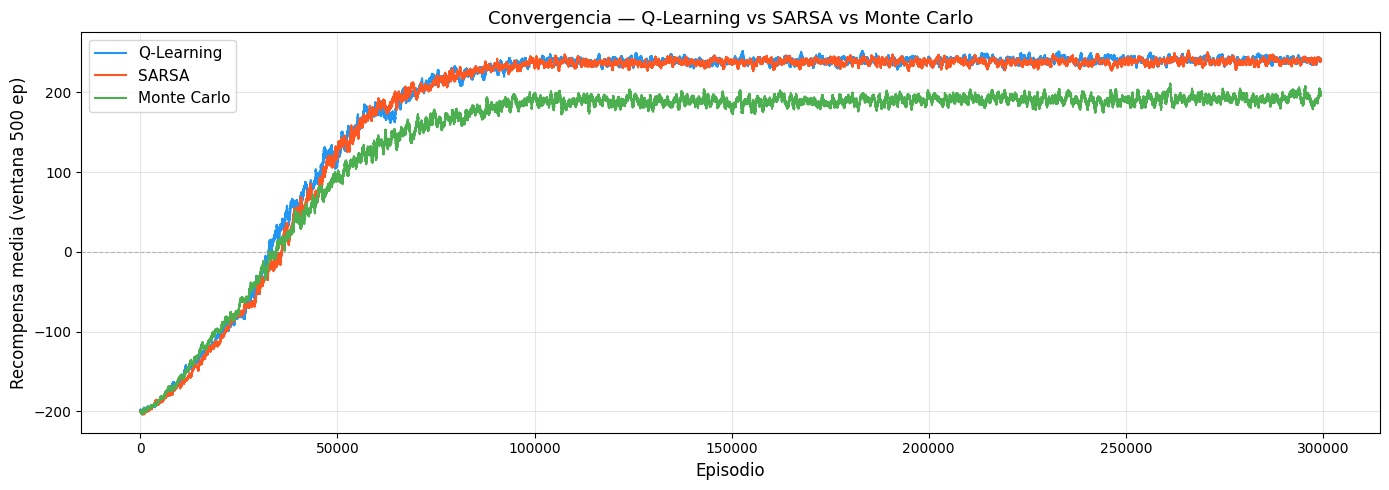

plots/convergencia.png


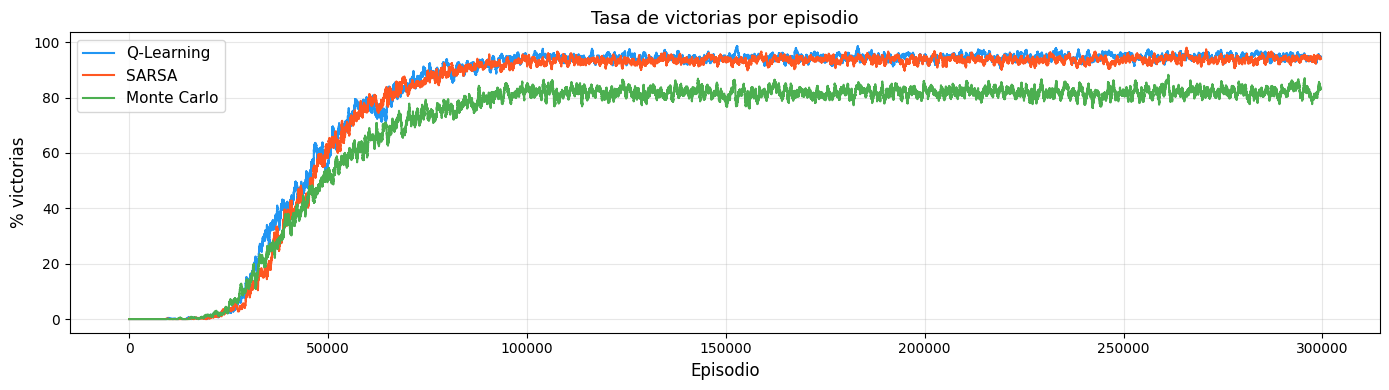

plots/victorias.png


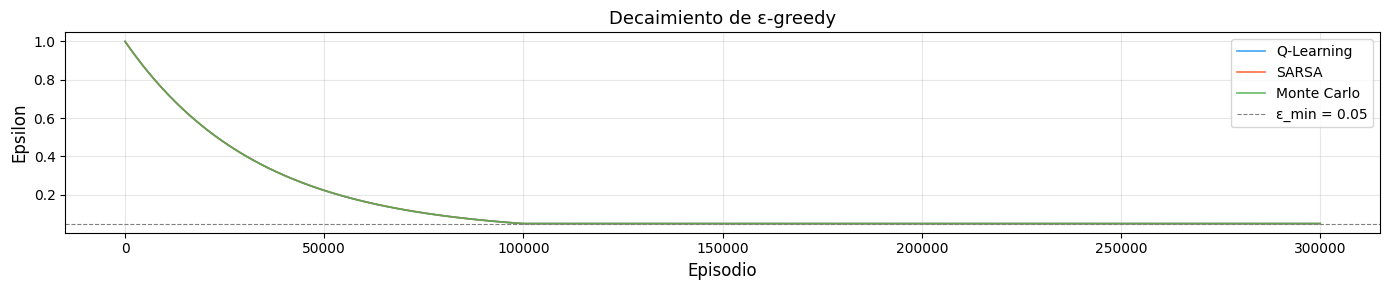

plots/epsilon.png


In [40]:
plot_convergencia()
plot_victorias()
plot_epsilon()

In [41]:
def plot_evaluacion_final():
    labels  = list(resultados.keys())
    colores = [COLORES_ALGO[n] for n in labels]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Boxplot recompensas
    datos = [res['eval']['recompensas'] for res in resultados.values()]
    bp    = axes[0].boxplot(datos, labels=labels, patch_artist=True,
                             medianprops={'color': 'white', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    axes[0].set_ylabel('Recompensa total', fontsize=11)
    axes[0].set_title('Distribución de recompensa — ε=0', fontsize=11)
    axes[0].grid(alpha=0.3, axis='y')

    # Barras tasa de victoria
    tasas = [resultados[n]['eval']['v_tasa'] * 100 for n in labels]
    bars  = axes[1].bar(labels, tasas, color=colores,
                        alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar, tasa in zip(bars, tasas):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5,
                     f'{tasa:.1f}%',
                     ha='center', va='bottom', fontsize=11)
    axes[1].set_ylabel('Tasa de victoria (%)', fontsize=11)
    axes[1].set_title('Tasa de victoria — ε=0', fontsize=11)
    axes[1].set_ylim(0, 105)
    axes[1].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('plots/evaluacion_final.png', dpi=150)
    plt.show()
    print("plots/evaluacion_final.png")


/var/folders/05/6jmrnggx2x14zbdvgbyf1zqh0000gn/T/ipykernel_7045/344922742.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp    = axes[0].boxplot(datos, labels=labels, patch_artist=True,


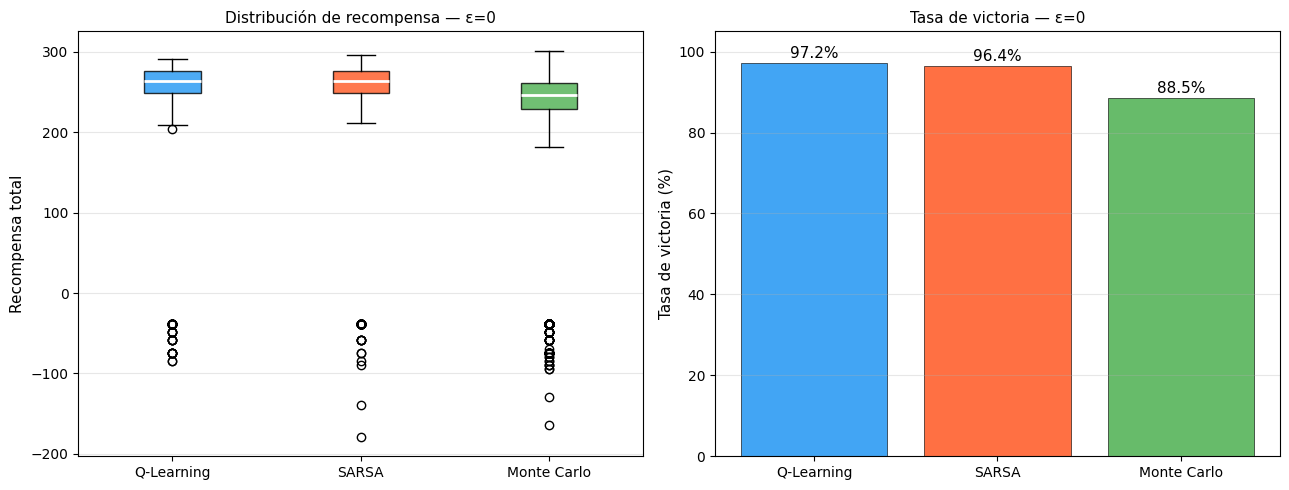

plots/evaluacion_final.png


In [42]:
plot_evaluacion_final()

**Mapas de política**: flechas en cada celda del grid mostrando la acción greedy aprendida para un estado fijo de cofres y provisiones. Permite visualizar si el agente aprendió a evitar el maelstrom y a aprovechar las corrientes. Las celdas sin flecha son estados raramente visitados (Q=0).

**Función de valor V(s)**: mapa de calor del valor máximo $V(s) = \max_a Q(s,a)$ por celda. Los valores altos cerca de corrientes confirman que el agente aprende a explotarlas; los valores bajos junto al maelstrom confirman la zona de evitación.

In [43]:
def plot_politica(nombre_algo, dir_viento=3):
    FLECHAS      = {0: '↑', 1: '↓', 2: '←', 3: '→'}
    NIVEL_LABELS = {0: 'CRITICO', 1: 'BAJO', 2: 'MEDIO', 3: 'ALTO'}
    COLORES_CELDA = {
        MAR:              '#1a5f7a',
        ISLA:             '#2d5a1b',
        TORMENTA_MOD:     '#3d2a6b',
        TORMENTA_SEV:     '#28155e',
        CORRIENTE:        '#14607a',
        MAELSTROM:        '#7a1010',
        PUERTO:           '#7a2800',
        COFRE_COMUN:      '#635014',
        COFRE_RARO:       '#7a5010',
        COFRE_EPICO:      '#4a1470',
        COFRE_LEGENDARIO: '#8a7000',
    }

    agente = agentes_cargados[nombre_algo]
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    fig.suptitle(
        f'Política aprendida — {nombre_algo} | Viento: {FLECHAS[dir_viento]}',
        fontsize=13
    )

    for ax, prov in zip(axes, [0, 1, 2, 3]):
        for r in range(8):
            for c in range(10):
                celda = MAPA_BASE[r][c]
                color = COLORES_CELDA.get(celda, COLORES_CELDA[MAR])
                rect  = mpatches.Rectangle(
                    (c, 7 - r), 1, 1,
                    facecolor=color,
                    edgecolor='#000', linewidth=0.4
                )
                ax.add_patch(rect)

                if celda != ISLA:
                    obs = (r, c, 1, 1, 1, 1, prov, dir_viento)
                    if obs in agente.Q:
                        mejor = int(np.argmax(agente.Q[obs]))
                        ax.text(c + 0.5, 7 - r + 0.5,
                               FLECHAS[mejor],
                               ha='center', va='center',
                               fontsize=9, fontweight='bold',
                               color='white')

        ax.set_xlim(0, 10)
        ax.set_ylim(0, 8)
        ax.set_title(f'Prov: {NIVEL_LABELS[prov]}', fontsize=11)
        ax.set_xticks(range(11))
        ax.set_yticks(range(9))
        ax.tick_params(labelsize=7)
        ax.grid(True, linewidth=0.3, color='#333')
        ax.set_aspect('equal')

    plt.tight_layout()
    fname = nombre_algo.lower().replace('-','_').replace(' ','_')
    plt.savefig(f'plots/politica_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"plots/politica_{fname}.png")


In [44]:
def plot_valor(nombre_algo, prov=2, dir_viento=3):
    agente = agentes_cargados[nombre_algo]
    V = np.full((8, 10), np.nan)

    for r in range(8):
        for c in range(10):
            if MAPA_BASE[r][c] != ISLA:
                obs = (r, c, 1, 1, 1, 1, prov, dir_viento)
                if obs in agente.Q:
                    V[r][c] = np.max(agente.Q[obs])

    fig, ax = plt.subplots(figsize=(13, 7))
    im = ax.imshow(V, cmap='RdYlGn', aspect='auto',
                   vmin=np.nanmin(V), vmax=np.nanmax(V))

    for r in range(8):
        for c in range(10):
            if not np.isnan(V[r][c]):
                ax.text(c, r, f'{V[r][c]:.0f}',
                       ha='center', va='center',
                       fontsize=7.5, color='black', fontweight='bold')
            elif MAPA_BASE[r][c] == ISLA:
                ax.add_patch(plt.Rectangle(
                    (c - 0.5, r - 0.5), 1, 1,
                    facecolor='#2d5a1b', edgecolor='none'))

    plt.colorbar(im, ax=ax, label='V(s) = max_a Q(s,a)', shrink=0.8)
    ax.set_title(
        f'Función de valor V(s) — {nombre_algo} | '
        f'Prov: {NIVEL_NOMBRES[prov]} | Viento: {DIR_FLECHAS[dir_viento]}',
        fontsize=12
    )
    ax.set_xticks(range(10))
    ax.set_yticks(range(8))
    plt.tight_layout()
    fname = nombre_algo.lower().replace('-','_').replace(' ','_')
    plt.savefig(f'plots/valor_{fname}.png', dpi=150)
    plt.show()
    print(f"plots/valor_{fname}.png")


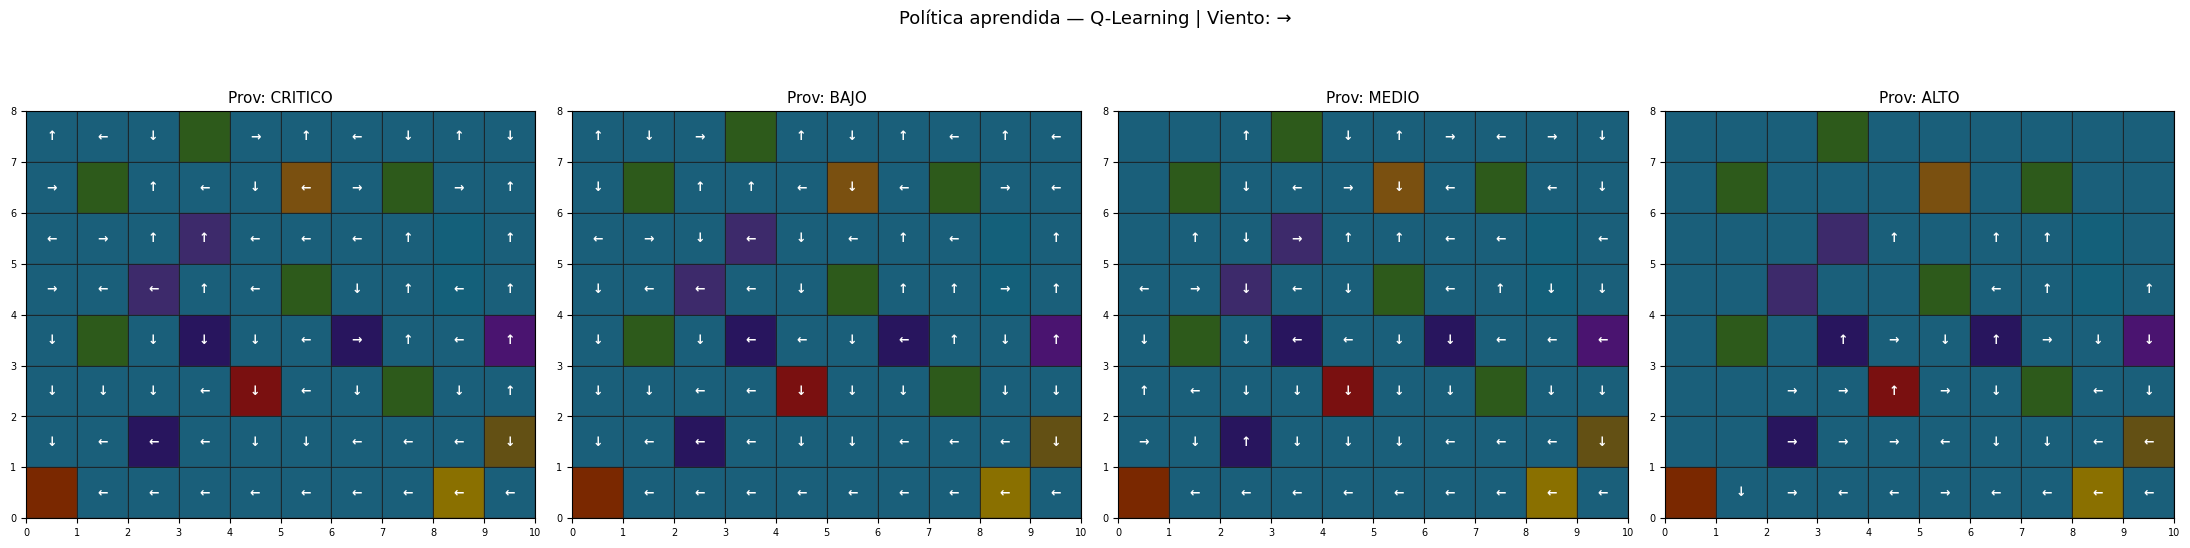

plots/politica_q_learning.png


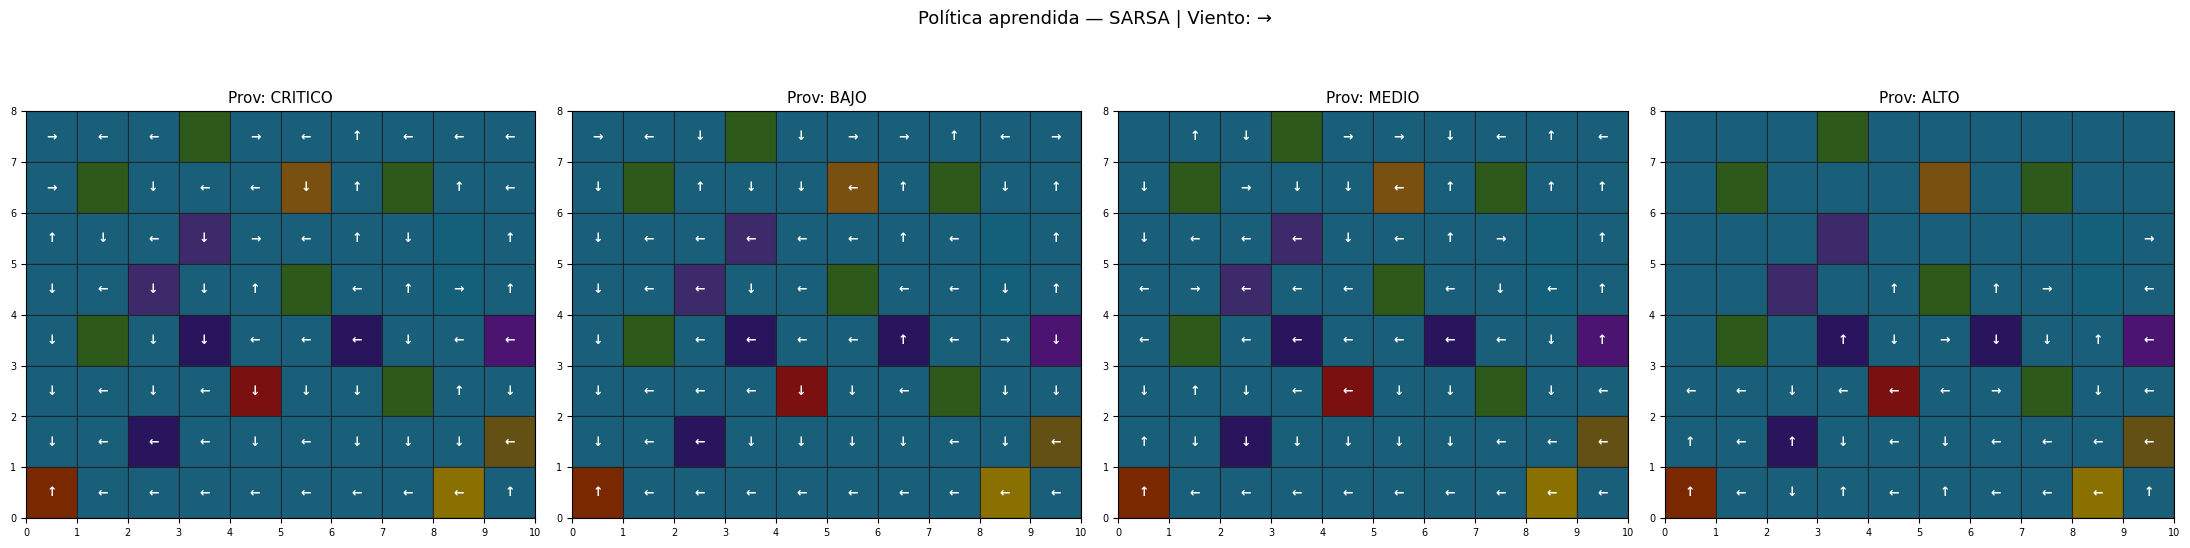

plots/politica_sarsa.png


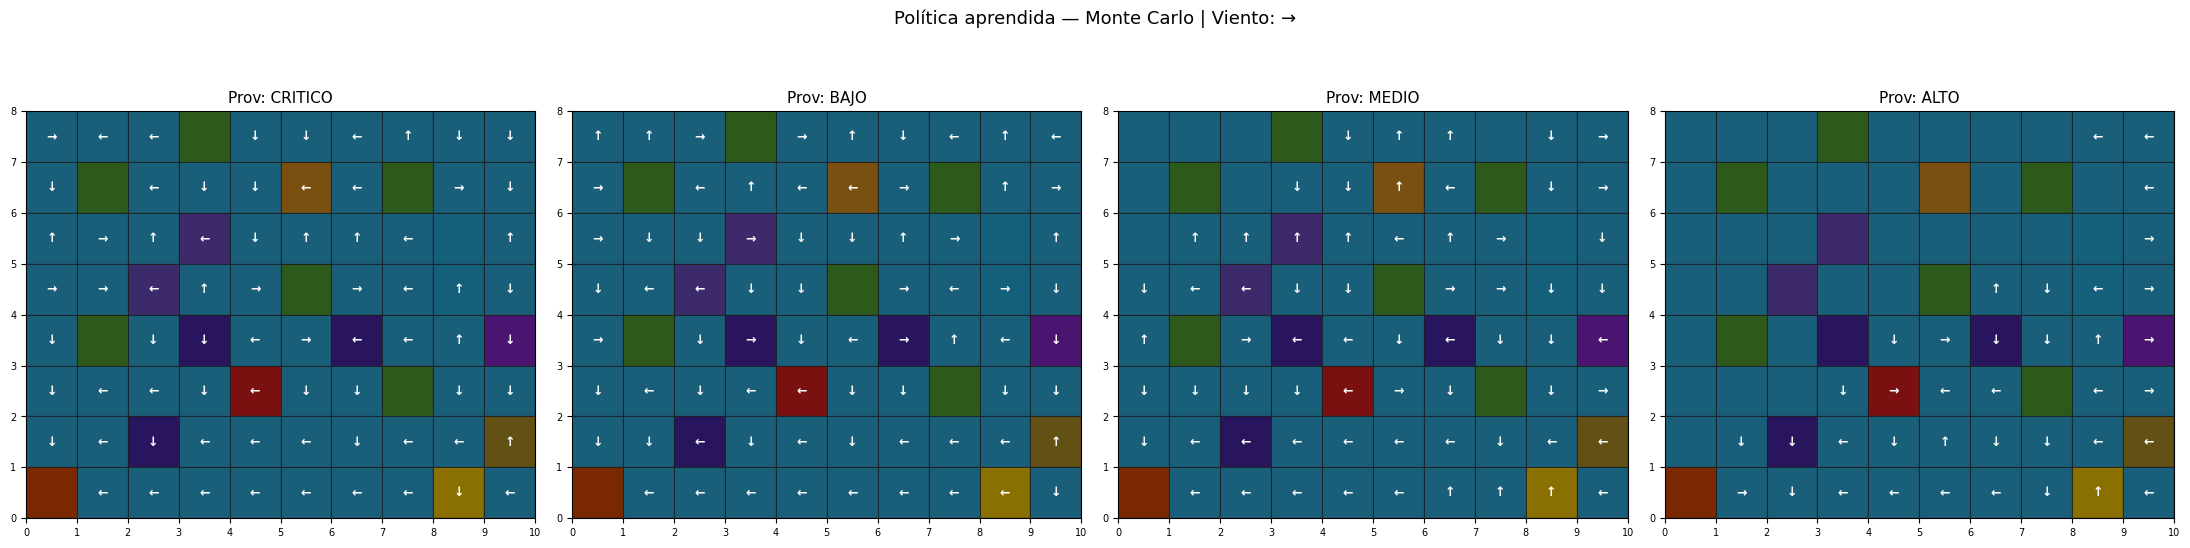

plots/politica_monte_carlo.png


In [45]:
plot_politica('Q-Learning')
plot_politica('SARSA')
plot_politica('Monte Carlo')

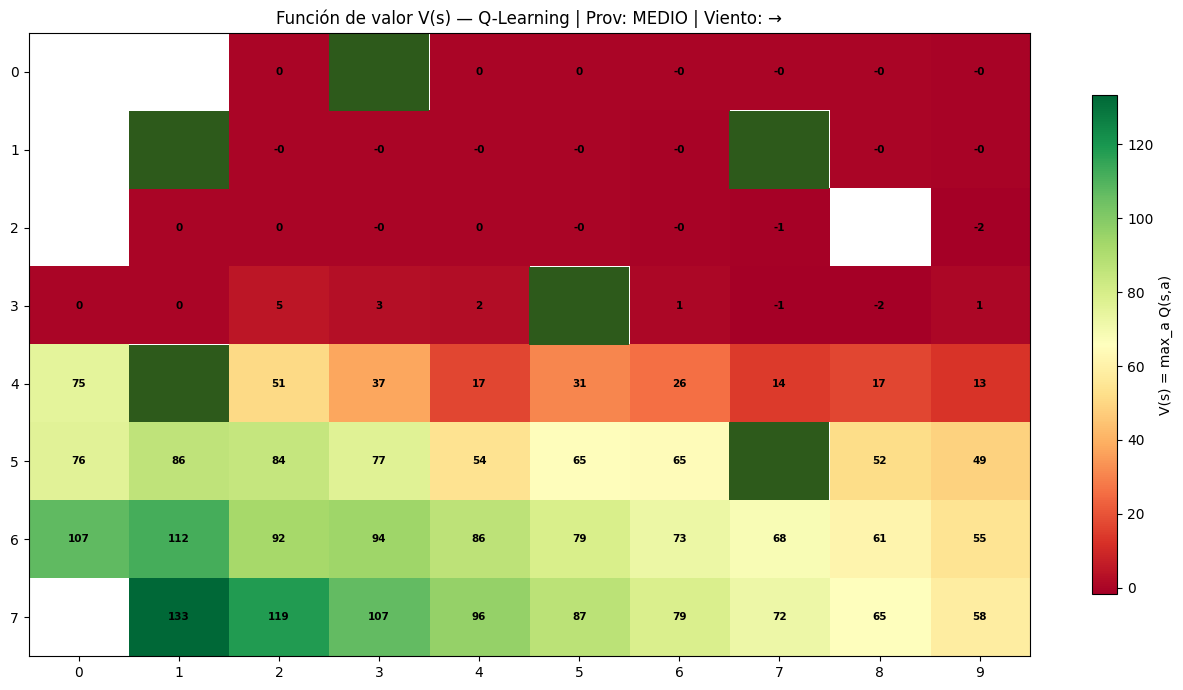

plots/valor_q_learning.png


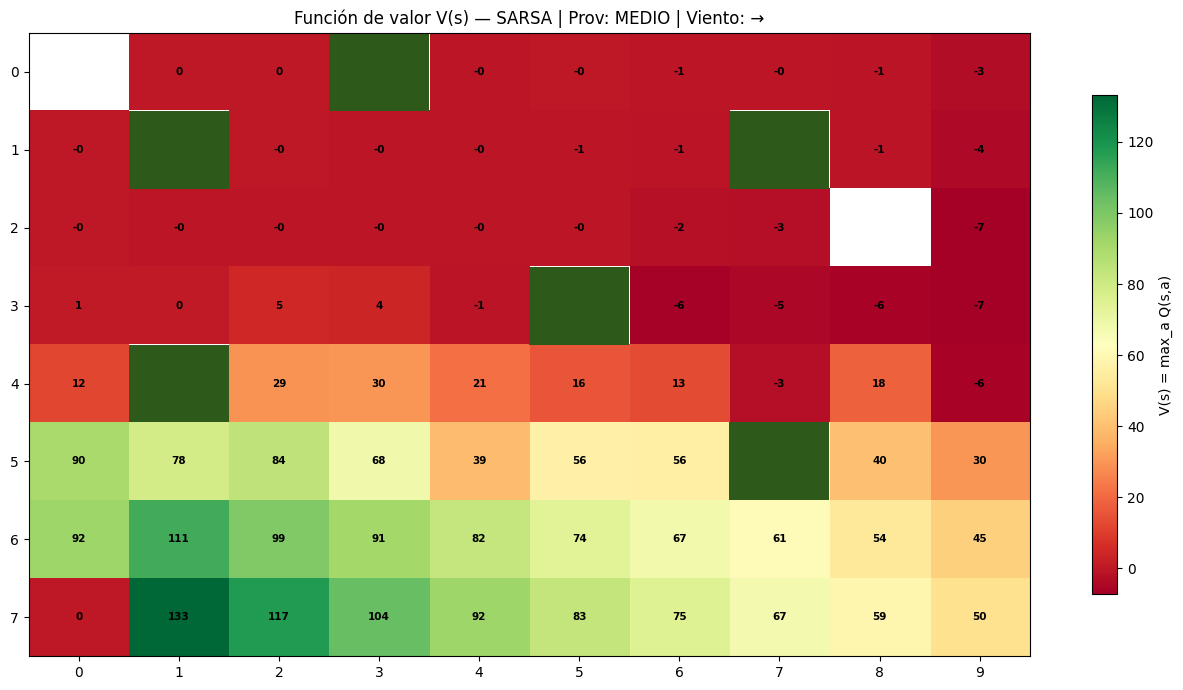

plots/valor_sarsa.png


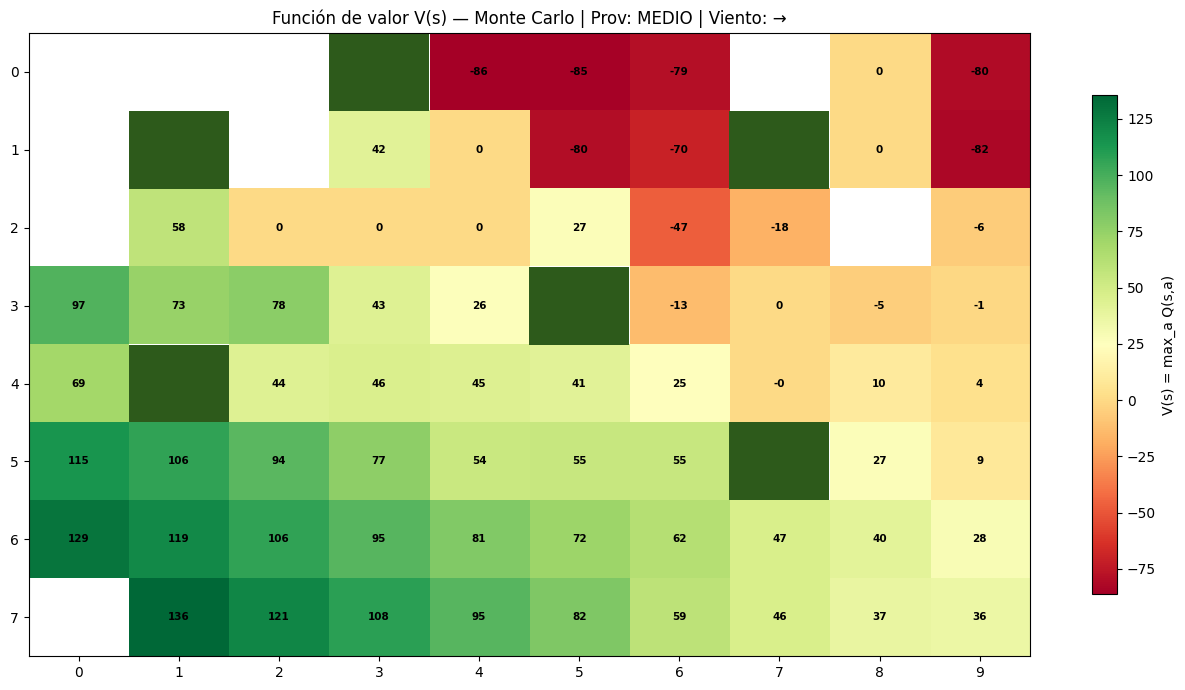

plots/valor_monte_carlo.png


In [46]:
plot_valor('Q-Learning')
plot_valor('SARSA')
plot_valor('Monte Carlo')

**Panel de política con las 4 direcciones de viento**. La justificación clave de incluir `dir_viento` en el estado es que la política óptima cambia según el viento. Este panel muestra Q-Learning con las cuatro direcciones simultáneamente. Si la política fuera la misma en los cuatro casos, incluir `dir_viento` habría sido innecesario, pero la diferencia es visible especialmente en las zonas de tormenta severa y en la ruta hacia el cofre épico (4,9).

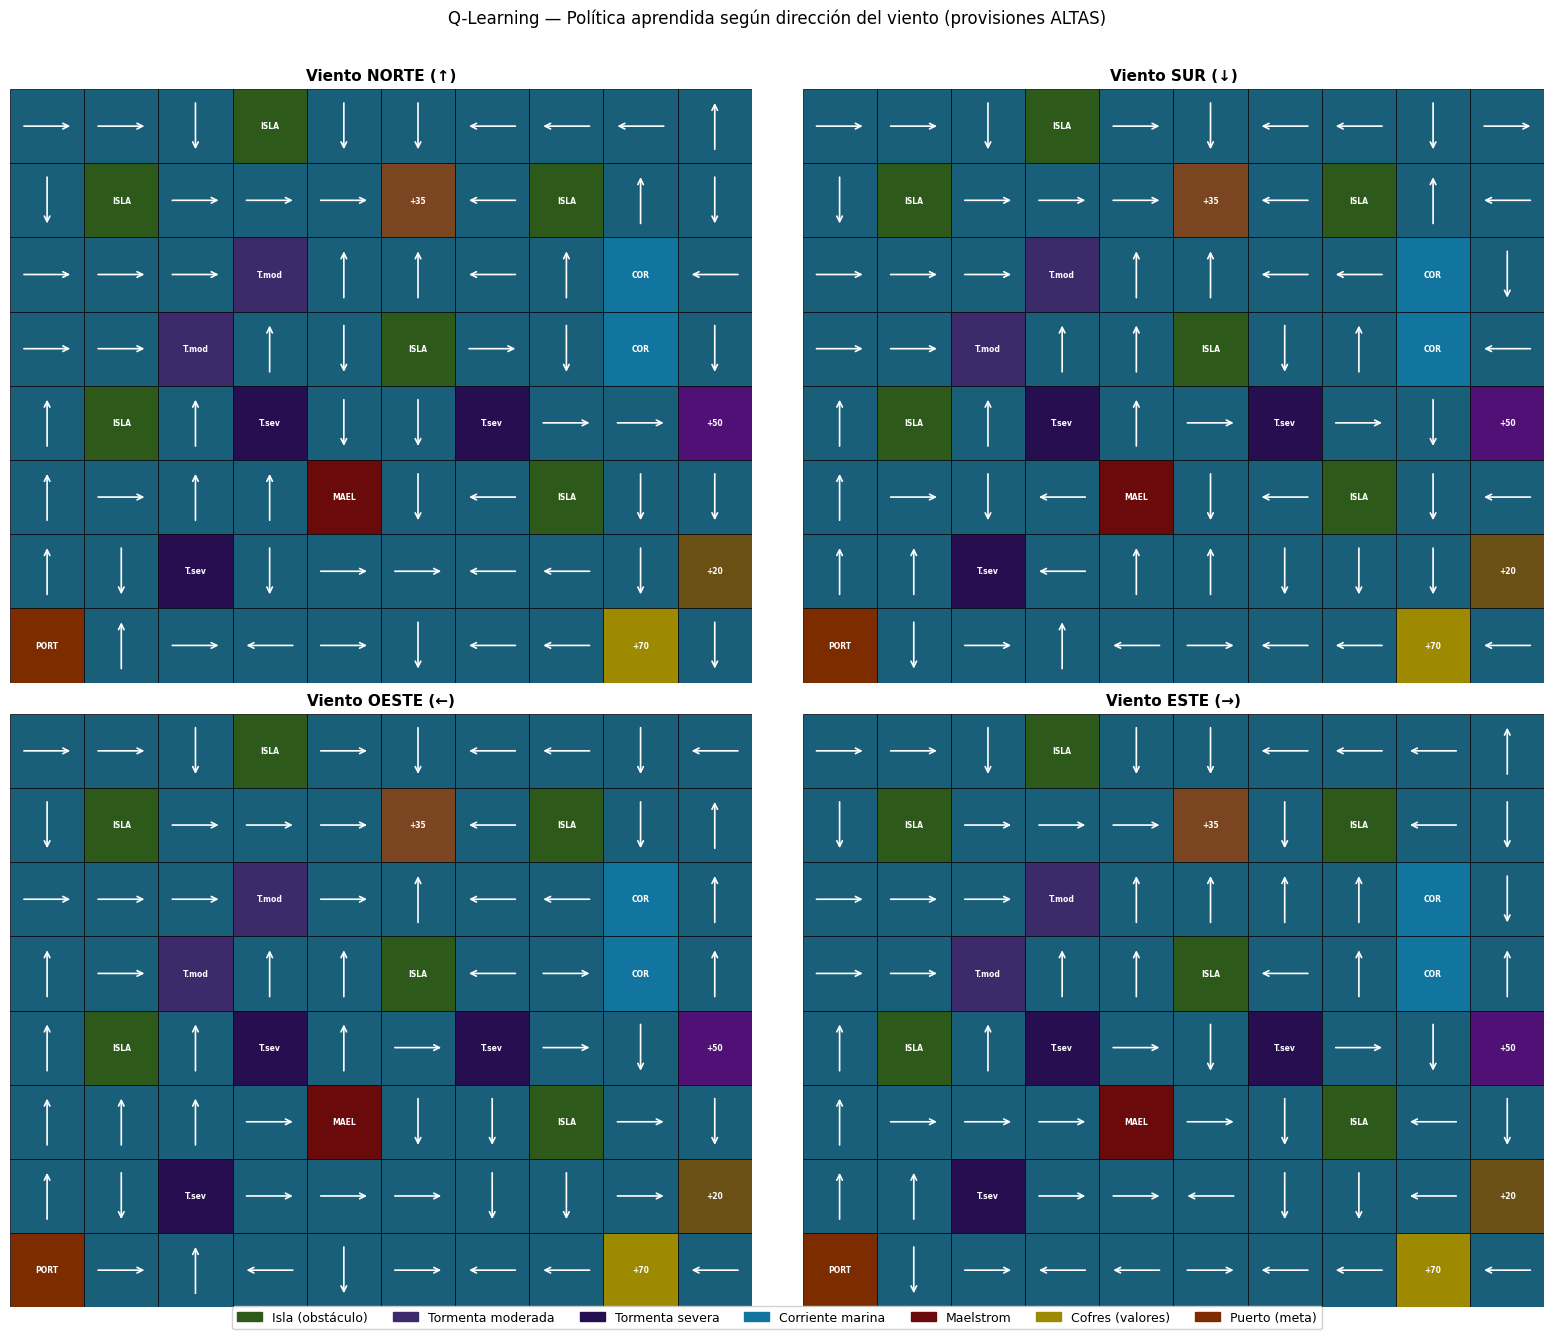

plots/politica_4_vientos.png


In [47]:
import matplotlib.patches as mpatches

DIR_NOMBRES_ES = {0: 'Viento NORTE (↑)', 1: 'Viento SUR (↓)',
                  2: 'Viento OESTE (←)', 3: 'Viento ESTE (→)'}

CELL_COLORS = {
    MAR: '#1a5f7a', ISLA: '#2d5a1b', TORMENTA_MOD: '#3d2a6b',
    TORMENTA_SEV: '#260e50', CORRIENTE: '#1275a0',
    MAELSTROM: '#6b0a0a', PUERTO: '#7d2c00',
    COFRE_COMUN: '#6b5015', COFRE_RARO: '#7a4520',
    COFRE_EPICO: '#501075', COFRE_LEGENDARIO: '#9e8a00',
}
CELL_LABELS = {
    ISLA: 'ISLA', TORMENTA_MOD: 'T.mod', TORMENTA_SEV: 'T.sev',
    CORRIENTE: 'COR', MAELSTROM: 'MAEL', PUERTO: 'PORT',
    COFRE_COMUN: '+20', COFRE_RARO: '+35',
    COFRE_EPICO: '+50', COFRE_LEGENDARIO: '+70',
}

def plot_politica_viento(ax, nombre_algo, dir_viento, nivel_prov=3):
    """Dibuja el mapa de política en un eje dado para una dirección de viento."""
    res = resultados[nombre_algo]
    Q = res['Q']

    ROWS, COLS = 8, 10
    ax.set_xlim(0, COLS)
    ax.set_ylim(0, ROWS)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_title(DIR_NOMBRES_ES[dir_viento], fontsize=11, fontweight='bold')
    ax.axis('off')

    arrow_dirs = {0: (0, -0.35), 1: (0, 0.35), 2: (-0.35, 0), 3: (0.35, 0)}

    for r in range(ROWS):
        for c in range(COLS):
            celda = MAPA_BASE[r][c]
            color = CELL_COLORS.get(celda, CELL_COLORS[MAR])
            rect = plt.Rectangle((c, r), 1, 1, facecolor=color,
                                  edgecolor='black', linewidth=0.5)
            ax.add_patch(rect)

            if celda in CELL_LABELS:
                ax.text(c + 0.5, r + 0.5, CELL_LABELS[celda],
                        ha='center', va='center', fontsize=5.5,
                        color='white', fontweight='bold')
                continue

            if celda == ISLA:
                continue

            # Cofres todos recogidos = estado previo al puerto
            for cofres_mask in [(1,1,1,1), (0,0,0,0)]:
                key = (r, c, *cofres_mask, nivel_prov, dir_viento)
                if key in Q:
                    q_vals = Q[key]
                    accion = int(np.argmax(q_vals))
                    dx, dy = arrow_dirs[accion]
                    ax.annotate('', xy=(c + 0.5 + dx, r + 0.5 + dy),
                                xytext=(c + 0.5 - dx, r + 0.5 - dy),
                                arrowprops=dict(arrowstyle='->', color='white',
                                                lw=1.2))
                    break


fig, axes = plt.subplots(2, 2, figsize=(16, 13))
axes = axes.flatten()

for dir_v in range(4):
    plot_politica_viento(axes[dir_v], 'Q-Learning', dir_viento=dir_v, nivel_prov=3)

# Leyenda de colores
legend_patches = [
    mpatches.Patch(color=CELL_COLORS[ISLA],           label='Isla (obstáculo)'),
    mpatches.Patch(color=CELL_COLORS[TORMENTA_MOD],   label='Tormenta moderada'),
    mpatches.Patch(color=CELL_COLORS[TORMENTA_SEV],   label='Tormenta severa'),
    mpatches.Patch(color=CELL_COLORS[CORRIENTE],      label='Corriente marina'),
    mpatches.Patch(color=CELL_COLORS[MAELSTROM],      label='Maelstrom'),
    mpatches.Patch(color=CELL_COLORS[COFRE_LEGENDARIO], label='Cofres (valores)'),
    mpatches.Patch(color=CELL_COLORS[PUERTO],         label='Puerto (meta)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=7,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(
    'Q-Learning — Política aprendida según dirección del viento (provisiones ALTAS)',
    fontsize=12, y=1.01
)

plt.tight_layout()
plt.savefig('plots/politica_4_vientos.png', dpi=150, bbox_inches='tight')
plt.show()
print('plots/politica_4_vientos.png')


### **Visualización con Pygame**

El entorno `PirateEnv` incluye un render completo con pygame que muestra el mapa con iconos emoji, colores por tipo de celda, y una barra de estado con provisiones, cofres recogidos y dirección del viento. Para ejecutarlo dentro de Jupyter (que no tiene display gráfico propio), capturamos cada frame como array RGB y lo mostramos con matplotlib.

Si se ejecuta desde linux el soporte gráfico nos permitirá ver los emojis. Con Mac la visualización se limita a cuadrados de colores, pero el entorno sigue siendo completamente funcional.

In [ ]:
import os
import time
import pickle
import platform  
import matplotlib.animation as animation
from IPython.display import HTML, display
from collections import defaultdict

# Configurar SDL en modo offscreen (sin ventana del SO) 
os.environ['SDL_VIDEODRIVER'] = 'dummy'
os.environ['SDL_AUDIODRIVER'] = 'dummy'


def render_pygame_jupyter(nombre_algo='Q-Learning', n_pasos=80, fps=4):
    """Ejecuta un episodio completo y renderiza cada paso con pygame,
    capturando frames y mostrándolos en el notebook como animación."""

    # Detectar si el sistema operativo es macOS
    es_mac = platform.system().lower() == "darwin"

    # Cargar agente desde resultados guardados
    with open('resultados_entrenamiento.pkl', 'rb') as f:
        resultados = pickle.load(f)

    res = resultados[nombre_algo]
    AgentClass = res['clase']
    agente = AgentClass(epsilon=0.0)
    agente.Q = defaultdict(lambda: np.zeros(4), res['Q'])

    # Inicializar entorno
    env_vis = PirateEnv(render_mode=None)
    obs, _ = env_vis.reset(seed=42)

    # Inicializar pygame en modo dummy
    pygame.init()
    CELL = 64
    W = env_vis.COLS * CELL
    H = env_vis.ROWS * CELL + 60
    pygame.display.init()
    screen = pygame.display.set_mode((W, H))

    COLORES = {
        MAR: (26,95,122), ISLA: (45,90,27),
        TORMENTA_MOD: (61,42,107), TORMENTA_SEV: (38,18,80),
        CORRIENTE: (18,110,155), MAELSTROM: (100,10,10) if not es_mac else (120,20,20),
        PUERTO: (130,45,0), 
        COFRE_COMUN: (100,80,20) if not es_mac else (204,164,61),
        COFRE_RARO: (110,65,30) if not es_mac else (184,134,11), 
        COFRE_EPICO: (80,20,110) if not es_mac else (138,43,226),
        COFRE_LEGENDARIO: (160,140,0) if not es_mac else (218,165,32),
    }

    # Configuración de fuentes según el sistema operativo
    font_sm = pygame.font.SysFont('Arial', 14)
    if es_mac:
        font_lg = pygame.font.SysFont('Arial', 15, bold=True)
    else:
        try:
            # Intentar cargar Noto Color Emoji (estándar en Linux)
            font_lg = pygame.font.Font('/usr/share/fonts/truetype/noto/NotoColorEmoji.ttf', int(CELL * 0.45))
        except:
            try:
                # Alternativa Windows
                font_lg = pygame.font.SysFont('Segoe UI Emoji', int(CELL * 0.45))
            except:
                font_lg = pygame.font.Font(None, int(CELL * 0.5))

    # Elementos si usamos Mac
    ETIQUETAS_MAC = {
        ISLA: 'ISLA', TORMENTA_MOD: 'MOD', TORMENTA_SEV: 'SEV',
        CORRIENTE: '>>>>', MAELSTROM: 'MAEL', PUERTO: 'PORT',
        COFRE_COMUN: 'C_CF', COFRE_RARO: 'R_CF',
        COFRE_EPICO: 'E_CF', COFRE_LEGENDARIO: 'L_CF',
    }

    ICONOS = {
        ISLA:'🌴', TORMENTA_MOD:'🌧️', TORMENTA_SEV:'⛈',
        CORRIENTE:'🌊', MAELSTROM:'🌀', PUERTO:'⚓',
        COFRE_COMUN:'📦', COFRE_RARO:'💰',
        COFRE_EPICO:'💎', COFRE_LEGENDARIO:'👑',
    }

    frames = []

    def draw_frame(env_state):
        screen.fill(COLORES[MAR])
        for r in range(env_vis.ROWS):
            for c in range(env_vis.COLS):
                x, y = c * CELL, r * CELL
                celda = env_vis.mapa[r][c]
                pygame.draw.rect(screen, COLORES.get(celda, COLORES[MAR]), (x, y, CELL, CELL))
                pygame.draw.rect(screen, (35, 35, 35), (x, y, CELL, CELL), 1)
                
                if es_mac:
                    # Mac sin emojis
                    if celda in ETIQUETAS_MAC:
                        color_texto = (255, 255, 255) if celda in [TORMENTA_MOD, TORMENTA_SEV, MAELSTROM, PUERTO, ISLA] else (0, 0, 0)
                        txt = font_lg.render(ETIQUETAS_MAC[celda], True, color_texto)
                        cx = x + (CELL - txt.get_width()) // 2
                        cy = y + (CELL - txt.get_height()) // 2
                        screen.blit(txt, (cx, cy))
                else:
                    # renderizado con emojis en Windows/Linux
                    if celda in ICONOS:
                        txt = font_lg.render(ICONOS[celda], True, (255, 255, 255))
                        if txt.get_width() > CELL:
                            txt = pygame.transform.smoothscale(txt, (int(CELL*0.6), int(CELL*0.6)))
                        cx = x + (CELL - txt.get_width()) // 2
                        cy = y + (CELL - txt.get_height()) // 2
                        screen.blit(txt, (cx, cy))

        # Dibujar Barco
        br = env_vis.ship_row * CELL
        bc = env_vis.ship_col * CELL
        if es_mac:
            # Barco geométrico en Mac
            bcx, bcy = bc + CELL // 2, br + CELL // 2
            pygame.draw.circle(screen, (255, 255, 255), (bcx, bcy), 16)
            pygame.draw.circle(screen, (0, 0, 0), (bcx, bcy), 16, 2)
            txt_barco = font_lg.render("B", True, (0, 0, 0))
            screen.blit(txt_barco, (bcx - txt_barco.get_width()//2, bcy - txt_barco.get_height()//2))
        else:
            # Barco emoji en Windows/Linux
            barco = font_lg.render('⛵', True, (255, 255, 255))
            if barco.get_width() > CELL:
                barco = pygame.transform.smoothscale(barco, (int(CELL*0.6), int(CELL*0.6)))
            cx = bc + (CELL - barco.get_width()) // 2
            cy = br + (CELL - barco.get_height()) // 2
            screen.blit(barco, (cx, cy))

        nivel = discretizar_provisiones(env_vis.provisiones)
        valor = sum(COFRES_INFO[i]['valor'] for i in range(4) if env_vis.cofres_recogidos[i])
        
        # Mapeo universal ASCII para las flechas del viento
        flechas_ascii = {0: '^', 1: 'v', 2: '<', 3: '>'}
        viento_str = flechas_ascii.get(env_vis.dir_viento, '?')

        hud = (f"Prov:{env_vis.provisiones} ({NIVEL_NOMBRES[nivel]}) | "
               f"Cofres:{sum(env_vis.cofres_recogidos)}/4 (+{valor}) | "
               f"Viento:{viento_str} | Paso:{env_vis.steps}")
               
        col = (240,80,80) if nivel==0 else (240,180,60) if nivel==1 else (255,255,255)
        screen.blit(font_sm.render(hud, True, col), (8, env_vis.ROWS * CELL + 15))
        pygame.display.flip()

        # Capturar como array
        frame = pygame.surfarray.array3d(screen)
        return np.transpose(frame, (1, 0, 2))  # (H, W, 3)

    # Asegurar el directorio plots
    os.makedirs('plots', exist_ok=True)

    # Ejecutar episodio 
    frames.append(draw_frame(None))
    done = False
    for _ in range(n_pasos):
        accion = agente.elegir_accion(obs)
        obs, reward, terminated, truncated, _ = env_vis.step(accion)
        frames.append(draw_frame(None))
        if terminated or truncated:
            break

    pygame.quit()
    env_vis.close()

    # Mostrar como animación matplotlib 
    fig_anim, ax_anim = plt.subplots(figsize=(10, 7))
    ax_anim.axis('off')
    title = ax_anim.set_title(f'{nombre_algo} — Frame 0/{len(frames)}', fontsize=13)
    im = ax_anim.imshow(frames[0])

    def update(i):
        im.set_data(frames[i])
        title.set_text(f'{nombre_algo} — Frame {i+1}/{len(frames)}')
        return [im, title]

    ani = animation.FuncAnimation(
        fig_anim, update, frames=len(frames),
        interval=1000//fps, blit=True
    )
    plt.tight_layout()

    # Guardar también como GIF
    ani.save('plots/render_pygame.gif', writer='pillow', fps=fps)
    print(f'plots/render_pygame.gif ({len(frames)} frames)')
    display(HTML(ani.to_jshtml()))
    plt.close()

render_pygame_jupyter('Q-Learning', n_pasos=80, fps=4)

plots/render_pygame.gif (37 frames)


### **Visualización paso a paso**

Esta visualización es análoga a la anterior pero sin usar pygame por si se tienen problemas de compatibilidad al ejecutar el render anterior.
Imprime un vídeo paso a paso de los movimientos que va haciendo el barco (solo durante la ejecución de la celda; para ver el video es necesario correrla).

> ℹ️ Cambia el argumento a `"SARSA"` o `"Monte Carlo"` para visualizar los otros agentes.

In [ ]:
from IPython.display import clear_output
import matplotlib.patches as mpatches
import time

def visualizar_matplotlib(nombre_algo, max_pasos=300, delay=0.15):
    COLORES = {
        MAR:              '#1a5f7a',
        ISLA:             '#2d5a1b',
        TORMENTA_MOD:     '#3d2a6b',
        TORMENTA_SEV:     '#28155e',
        CORRIENTE:        '#14607a',
        MAELSTROM:        '#7a1010',
        PUERTO:           '#7a2800',
        COFRE_COMUN:      '#635014',
        COFRE_RARO:       '#7a5010',
        COFRE_EPICO:      '#4a1470',
        COFRE_LEGENDARIO: '#8a7000',
    }
    
    # Etiquetas de texto limpias en ASCII
    LABELS = {
        ISLA:             ('ISLA',  '#a3d977', 7),
        TORMENTA_MOD:     ('T.MOD', '#c4a6f0', 7),
        TORMENTA_SEV:     ('T.SEV', '#e8a0ff', 7),
        CORRIENTE:        ('COR',   '#7ad4f0', 7),
        MAELSTROM:        ('MAE',   '#f87171', 8),
        PUERTO:           ('PTO',   '#fdba74', 9),
        COFRE_COMUN:      ('+20',   '#fde68a', 9),
        COFRE_RARO:       ('+35',   '#fcd34d', 9),
        COFRE_EPICO:      ('+50',   '#e879f9', 9),
        COFRE_LEGENDARIO: ('+70',   '#fef08a', 10),
    }

    # Cargamos la instancia entrenada desde el diccionario de resultados
    with open('resultados_entrenamiento.pkl', 'rb') as f:
        resultados_guardados = pickle.load(f)
        
    res = resultados_guardados[nombre_algo]
    AgentClass = res['clase']
    
    # Reconstrucción del agente
    agente = AgentClass(epsilon=0.0)
    agente.Q = defaultdict(lambda: np.zeros(4), res['Q'])

    # Inicialización del entorno para visualización
    env_vis        = PirateEnv(render_mode=None)
    obs, _         = env_vis.reset(seed=SEED)
    done           = False
    total          = 0
    pasos          = 0
    info           = {}

    print(f"Visualizando trayectoria de {nombre_algo} - ε=0")

    while not done and pasos < max_pasos:
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(13, 7))
        ax.set_facecolor('#0d1b2a')
        fig.patch.set_facecolor('#0d1b2a')

        # Celdas
        for r in range(env_vis.ROWS):
            for c in range(env_vis.COLS):
                celda = env_vis.mapa[r][c]
                color = COLORES.get(celda, COLORES[MAR])
                
                rect  = mpatches.Rectangle(
                    (c, 7 - r), 1, 1,
                    linewidth=0.4,
                    edgecolor='#1e3a5f',
                    facecolor=color
                )
                ax.add_patch(rect)

                # Imprimir etiquetas de texto encima del fondo
                if celda in LABELS:
                    txt, col, fs = LABELS[celda]
                    ax.text(c + 0.5, 7 - r + 0.5, txt,
                            ha='center', va='center',
                            fontsize=fs, color=col,
                            fontweight='bold', fontfamily='monospace')

        # Barco como estrella
        ax.plot(env_vis.ship_col + 0.5,
                7 - env_vis.ship_row + 0.5,
                marker='*', markersize=22,
                color='white', markeredgecolor='#58a6ff',
                markeredgewidth=1.5, zorder=10)

        # Por si el barco está atrapado en un maelstrom, dibujar un círculo rojo alrededor
        if env_vis.turnos_atrapado > 0:
            ax.plot(env_vis.ship_col + 0.5,
                    7 - env_vis.ship_row + 0.5,
                    marker='o', markersize=30,
                    color='none', markeredgecolor='#f87171',
                    markeredgewidth=2.5, zorder=9)

        # Leyenda
        nivel  = NIVEL_NOMBRES[discretizar_provisiones(env_vis.provisiones)]
        valor  = sum(COFRES_INFO[i]['valor']
                     for i in range(4) if env_vis.cofres_recogidos[i])
        
        flechas_ascii = {0: '^', 1: 'v', 2: '<', 3: '>'}
        viento_str = flechas_ascii.get(env_vis.dir_viento, '?')

        titulo = (f"{nombre_algo}  |  Paso {pasos}  |  "
                  f"Prov: {env_vis.provisiones} ({nivel})  |  "
                  f"Cofres: {sum(env_vis.cofres_recogidos)}/4 (+{valor})  |  "
                  f"Viento: {viento_str}  |  "
                  f"R acum: {total:+.0f}")
                  
        if env_vis.turnos_atrapado > 0:
            titulo += f"  |  ** MAELSTROM ATENCION ({env_vis.turnos_atrapado}t) **"

        col_titulo = '#f87171' if nivel == 'CRÍTICO' else \
                     '#fbbf24' if nivel == 'BAJO'    else '#e2e8f0'
        ax.set_title(titulo, color=col_titulo, fontsize=9,
                     pad=8, fontfamily='monospace')

        # Leyenda de colores 
        handles = [
            mpatches.Patch(color=COLORES[MAR],              label='Mar Open'),
            mpatches.Patch(color=COLORES[ISLA],             label='Isla / Obst'),
            mpatches.Patch(color=COLORES[TORMENTA_MOD],     label='Torm. Moderada'),
            mpatches.Patch(color=COLORES[TORMENTA_SEV],     label='Torm. Severa'),
            mpatches.Patch(color=COLORES[CORRIENTE],        label='Corriente Marina'),
            mpatches.Patch(color=COLORES[MAELSTROM],        label='Maelstrom Peligro'),
            mpatches.Patch(color=COLORES[PUERTO],           label='Puerto Base'),
            mpatches.Patch(color=COLORES[COFRE_COMUN],      label='Cofre Comun +20'),
            mpatches.Patch(color=COLORES[COFRE_RARO],       label='Cofre Raro +35'),
            mpatches.Patch(color=COLORES[COFRE_EPICO],      label='Cofre Epico +50'),
            mpatches.Patch(color=COLORES[COFRE_LEGENDARIO], label='Cofre Legend +70'),
        ]
        ax.legend(handles=handles, loc='upper right',
                  fontsize=7.5, framealpha=0.3,
                  labelcolor='white', facecolor='#0d1b2a',
                  edgecolor='#1e3a5f',
                  ncol=2, handlelength=1)

        ax.set_xlim(0, 10)
        ax.set_ylim(0, 8)
        ax.set_aspect('equal')
        ax.set_xticks(range(11))
        ax.set_yticks(range(9))
        ax.tick_params(colors='#4a6fa5', labelsize=7)
        for spine in ax.spines.values():
            spine.set_edgecolor('#1e3a5f')

        plt.tight_layout()
        plt.show()
        time.sleep(delay)

        accion = agente.elegir_accion(obs)
        obs, r, term, trunc, info = env_vis.step(accion)
        done   = term or trunc
        total += r
        pasos += 1

    # Cierre de la simulación
    env_vis.close()
    clear_output(wait=True)
    
    # Resumen final
    victoria_real = sum(env_vis.cofres_recogidos) == 4 and (env_vis.ship_row, env_vis.ship_col) == PUERTO_POS

    print(f"{'='*52}")
    print(f"  {nombre_algo} — Episodio de Evaluación Finalizado")
    print(f"{'='*52}")
    print(f"  Pasos ejecutados:   {pasos}")
    print(f"  Recompensa neta:    {total:+.1f}")
    print(f"  Cofres cargados:    {sum(env_vis.cofres_recogidos)}/4")
    print(f"  Resultado oficial:  {'Victoria' if victoria_real else 'Deerrota'}")
    print(f"{'='*52}")

visualizar_matplotlib("SARSA", delay=0.2)

  SARSA — Episodio de Evaluación Finalizado
  Pasos ejecutados:   39
  Recompensa neta:    +276.5
  Cofres cargados:    4/4
  Resultado oficial:  Victoria


---

### **Búsqueda de hiperparámetros**

Para justificar la elección de hiperparámetros y demostrar que no son valores arbitrarios, hemos realizado una búsqueda sistemática variando dos parámetros clave para cada algoritmo:

- **Factor de descuento $\gamma \in \{0.95, 0.97, 0.99\}$**: controla cuánto peso da el agente a recompensas futuras. Un $\gamma$ alto hace que el agente planifique a más largo plazo.
- **Exploración residual $\epsilon_{\min} \in \{0.01, 0.05, 0.10\}$**: nivel mínimo de exploración aleatoria tras el decaimiento. Valores más altos mantienen al agente explorando durante más tiempo.

Cada configuración se entrena con **300.000 episodios** (como en el entrenamiento base) y se evalúa con **2.000 episodios greedy** ($\epsilon=0$). Los resultados se comparan contra la configuración base ($\gamma=0.97$, $\epsilon_{\min}=0.05$) que utilizamos en el apartado anterior.

In [59]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Cargamos los archivos de resultados
exp_files = {
    'Q-Learning':  'resultados_exp_qlearning.pkl',
    'SARSA':       'resultados_exp_sarsa.pkl',
    'Monte Carlo': 'resultados_exp_montecarlo.pkl',
}

exp_data = {}
for algo, path in exp_files.items():
    if os.path.exists(path):
        with open(path, 'rb') as f:
            exp_data[algo] = pickle.load(f)
        print(f" {algo}: {len(exp_data[algo])} experimentos cargados")
    else:
        print(f" {path} no encontrado")
    
# Resultados del entrenamiento original
base_results = {
    'Q-Learning':  {'victoria': 97.2, 'recompensa': 253.3, 'std': 54.1},
    'SARSA':       {'victoria': 96.4, 'recompensa': 252.0, 'std': 60.7},
    'Monte Carlo': {'victoria': 88.5, 'recompensa': 215.7, 'std': 97.7},
}

# Resumen
print(f"\n{'='*70}")
print(f"  Resumen de búsqueda")
print(f"{'='*70}")

for algo, experiments in exp_data.items():
    print(f"\n─── {algo} ───")
    base = base_results[algo]
    print(f"  {'Config':<28} {'Victoria':>10} {'R media':>12} {'± std':>8}")
    print(f"  {'─'*60}")
    print(f"  {'BASE (γ=0.97, ε_min=0.05)':<28} {base['victoria']:>9.1f}% {base['recompensa']:>11.1f} {base['std']:>7.1f}")
    for exp_name, res in experiments.items():
        v = np.mean(res['eval']['victorias']) * 100
        r = np.mean(res['eval']['recompensas'])
        s = np.std(res['eval']['recompensas'])
        tag = exp_name.split('_', 1)[1] if '_' in exp_name else exp_name
        marker = ' *' if v > base['victoria'] else ''
        print(f"  {tag:<28} {v:>9.1f}% {r:>11.1f} {s:>7.1f}{marker}")


 Q-Learning: 4 experimentos cargados
 SARSA: 4 experimentos cargados
 Monte Carlo: 4 experimentos cargados

  Resumen de búsqueda

─── Q-Learning ───
  Config                         Victoria      R media    ± std
  ────────────────────────────────────────────────────────────
  BASE (γ=0.97, ε_min=0.05)         97.2%       253.3    54.1
  gamma_0.95                        97.8%       257.8    49.9 *
  gamma_0.99                        97.2%       254.1    55.0
  eps_0.01                          97.0%       253.1    55.2
  eps_0.10                          98.1%       258.9    46.1 *

─── SARSA ───
  Config                         Victoria      R media    ± std
  ────────────────────────────────────────────────────────────
  BASE (γ=0.97, ε_min=0.05)         96.4%       252.0    60.7
  gamma_0.95                        97.8%       259.0    49.5 *
  gamma_0.99                        97.4%       256.4    53.1 *
  eps_0.01                          97.5%       256.0    52.5 *
  eps_0.10   

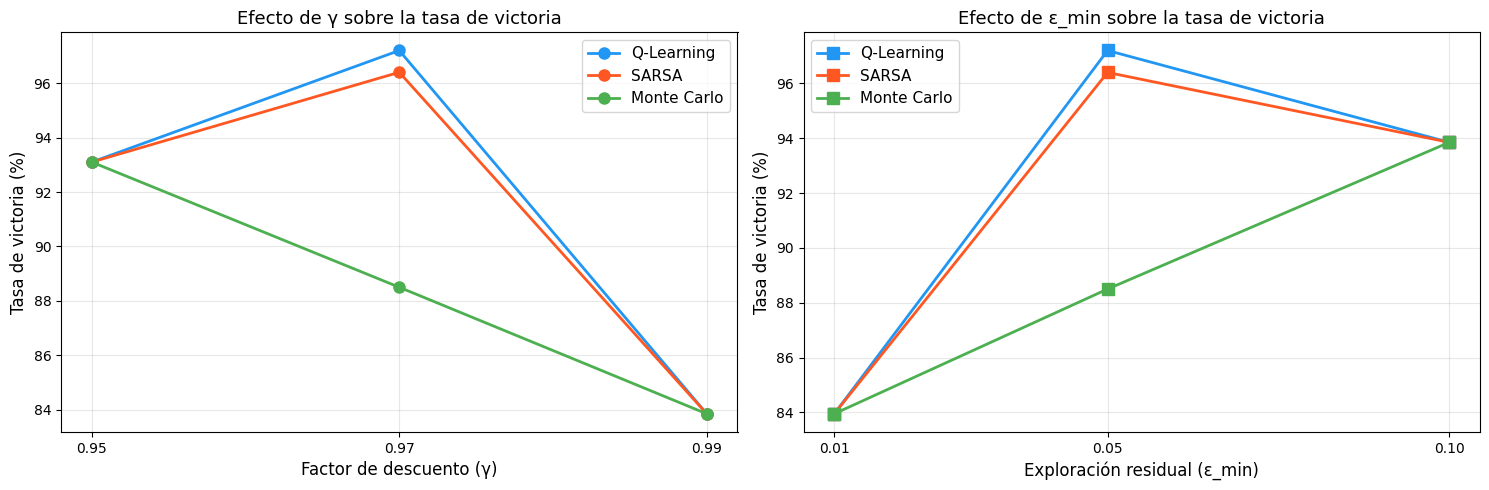

plots/hiperparametros_victoria.png


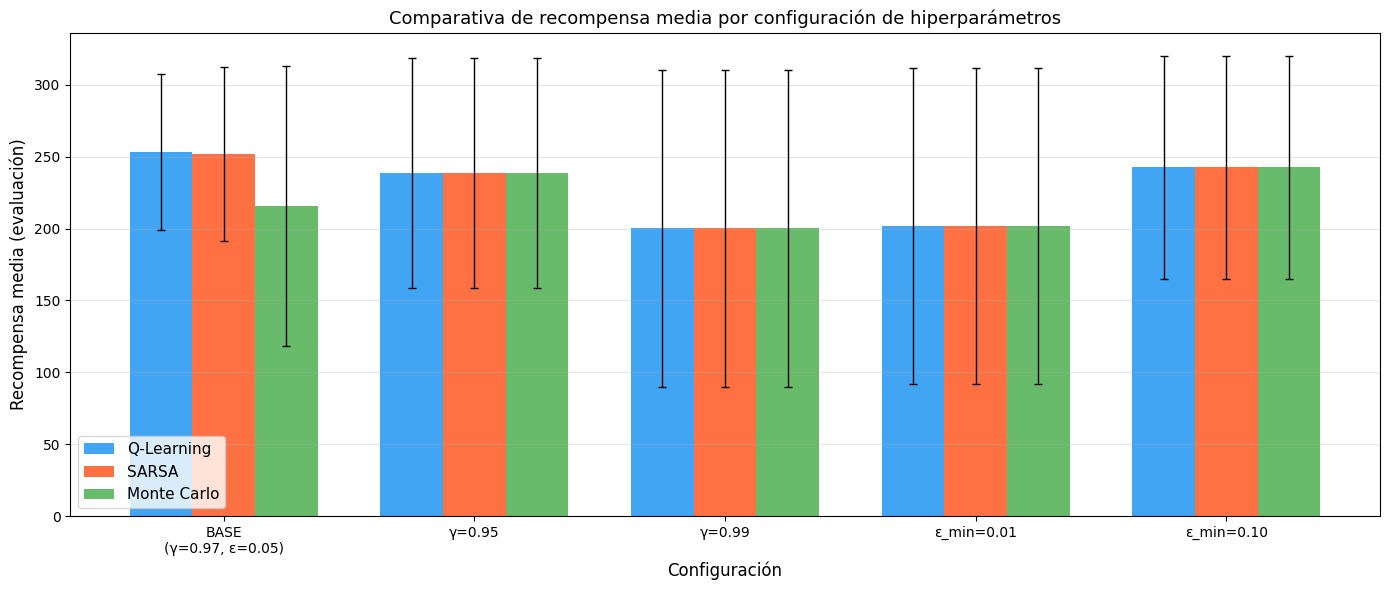

plots/hiperparametros_recompensa.png


In [ ]:
# Comparativas de hiperparámetros

COLORES_ALGORITMOS = {
    'Q-Learning':  '#2196F3',
    'SARSA':       '#FF5722',
    'Monte Carlo': '#4CAF50',
}

# Efecto de gamma sobre la tasa de victoria 
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

gammas = [0.95, 0.97, 0.99]
for nombre_algoritmo, datos_experimentos in exp_data.items():
    victorias = []
    for g in gammas:
        if g == 0.97:
            victorias.append(base_results[nombre_algoritmo]['victoria'])
        else:
            key = f"{algo}_gamma_{g:.2f}"
            if key in experiments:
                victorias.append(np.mean(experiments[key]['eval']['victorias']) * 100)
            else:
                victorias.append(None)
    axes[0].plot(gammas, victorias, 'o-', color=COLORES_ALGORITMOS[nombre_algoritmo],
                 label=nombre_algoritmo, linewidth=2, markersize=8)

axes[0].set_xlabel('Factor de descuento (γ)', fontsize=12)
axes[0].set_ylabel('Tasa de victoria (%)', fontsize=12)
axes[0].set_title('Efecto de γ sobre la tasa de victoria', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(gammas)

# ¡Efecto de ε_min sobre la tasa de victoria
epsilons = [0.01, 0.05, 0.10]
for nombre_algoritmo, datos_experimentos in exp_data.items():
    victorias = []
    for e in epsilons:
        if e == 0.05:
            victorias.append(base_results[nombre_algoritmo]['victoria'])
        else:
            key = f"{algo}_eps_{e:.2f}"
            if key in experiments:
                victorias.append(np.mean(experiments[key]['eval']['victorias']) * 100)
            else:
                victorias.append(None)
    axes[1].plot(epsilons, victorias, 's-', color=COLORES_ALGORITMOS[nombre_algoritmo],
                 label=nombre_algoritmo, linewidth=2, markersize=8)

axes[1].set_xlabel('Exploración residual (ε_min)', fontsize=12)
axes[1].set_ylabel('Tasa de victoria (%)', fontsize=12)
axes[1].set_title('Efecto de ε_min sobre la tasa de victoria', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(epsilons)

plt.tight_layout()
plt.savefig('plots/hiperparametros_victoria.png', dpi=150)
plt.show()
print("plots/hiperparametros_victoria.png")

fig, ax = plt.subplots(figsize=(14, 6))

configs = ['BASE\n(γ=0.97, ε=0.05)', 'γ=0.95', 'γ=0.99', 'ε_min=0.01', 'ε_min=0.10']
x = np.arange(len(configs))
width = 0.25

for i, (nombre_algoritmo, datos_experimentos) in enumerate(exp_data.items()):
    rewards = [base_results[nombre_algoritmo]['recompensa']]
    stds = [base_results[nombre_algoritmo]['std']]
    
    for key_suffix in ['gamma_0.95', 'gamma_0.99', 'eps_0.01', 'eps_0.10']:
        key = f"{algo}_{key_suffix}"
        if key in experiments:
            rewards.append(np.mean(experiments[key]['eval']['recompensas']))
            stds.append(np.std(experiments[key]['eval']['recompensas']))
        else:
            rewards.append(0)
            stds.append(0)
    
    ax.bar(x + (i - 1) * width, rewards, width, yerr=stds,
           label=nombre_algoritmo, color=COLORES_ALGORITMOS[nombre_algoritmo], alpha=0.85,
           capsize=3, error_kw={'linewidth': 1})

ax.set_xlabel('Configuración', fontsize=12)
ax.set_ylabel('Recompensa media (evaluación)', fontsize=12)
ax.set_title('Comparativa de recompensa media por configuración de hiperparámetros', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=10)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
ax.axhline(0, color='gray', linewidth=0.5)

plt.tight_layout()
plt.savefig('plots/hiperparametros_recompensa.png', dpi=150)
plt.show()
print("plots/hiperparametros_recompensa.png")


### **Análisis de la búsqueda de hiperparámetros**

1. **Efecto del factor de descuento $\gamma$**

El factor de descuento controla cuánto peso da el agente a las recompensas futuras. Tanto en `Q-Learning` como en `SARSA`, 0.97 nos da los mejores resultados, por lo que el análisis que hicimos inicialmente es correcto. En cualquier caso, hay bastante diferencia de resultados entre 0.95, 0.97 y 0.99, lo que confirma que la elección de $\gamma$ no es arbitraria. En `Monte Carlo` el mejor resultado se obtiene con $\gamma=0.95$, lo que es lógico porque al no hacer bootstrapping el agente se ve más afectado por la varianza de las recompensas futuras, ya que un $\gamma$ más bajo reduce ese impacto.

2.  **Efecto de la exploración residual $\epsilon_{\min}$**

La exploración residual controla el nivel mínimo de exploración que el agente mantendrá durante el entrenamiento. En `Q-Learning` y `SARSA`, un $\epsilon_{\min}$ medio (0.05) tiende a dar mejores resultados, lo que sugiere que mantener un nivel de exploración más alto puede ser beneficioso en entornos más complejos. En `Monte Carlo`, una vez más, se prefiere un $\epsilon_{\min}$ más alto, ya que probablemente se necesita más exploración (aunque más moderada con un $\gamma$ menor) para compensar la falta de bootstrapping y la mayor varianza en las actualizaciones.

En cualquier caso, estas graficas son especialmente importantes porque reflejan como cambian los resultados al variar los hiperparámetros aunque sea mínimamente.

---

### **Análisis de sensibilidad: eliminación del maelstrom**

Vamos a verificar que el agente aprende a evitar el maelstrom (y no simplemente lo esquiva por casualidad). Lo eliminaremos del mapa y se reentrena Q-Learning con la misma configuración base. Si el agente realmente estaba evitando el maelstrom de forma activa, esperamos ver:

1. **Mayor tasa de victoria**: sin la trampa del maelstrom, más episodios terminan exitosamente.
2. **Rutas más directas**: el agente podrá cruzar la zona central del mapa.
3. **Menos pasos medios**: eliminar la penalización de 2 turnos atrapado reduce la longitud de los episodios.

In [64]:
import pickle
import numpy as np

ABLATION_PATH = 'resultados_ablacion_maelstrom.pkl'
with open(ABLATION_PATH, 'rb') as f:
    ablation_results = pickle.load(f)

# Métricas del entorno base original 
v_base = 97.2  
r_base = 253.3
s_base = 54.1
p_base = 45.3  

# Extracción de métricas del experimento sin Maelstrom
e = ablation_results['eval']
v_abl = np.mean(e['victorias']) * 100
r_abl = np.mean(e['recompensas'])
s_abl = np.std(e['recompensas'])
p_abl = np.mean(e['pasos'])  

print(f"\n{'='*65}")
print(f"  Comparativa de Ablación: Con vs. Sin Maelstrom (Q-Learning)")
print(f"{'='*65}")
print(f"  {'Métrica':<25} {'Con Maelstrom (Base)':>20} {'Sin Maelstrom':>16}")
print(f"  {'─'*65}")
print(f"  {'Tasa de victoria':<25} {v_base:>19.1f}% {v_abl:>15.1f}%")
print(f"  {'Recompensa media':<25} {r_base:>19.1f}  {r_abl:>15.1f}")
print(f"  {'Desviación estándar':<25} {s_base:>19.1f}  {s_abl:>15.1f}")
print(f"  {'Pasos medios':<25} {p_base:>19.1f}  {p_abl:>15.1f}")  
print(f"  {'─'*65}")
print(f"  {'Δ Tasa victoria':<25} {'':>20} {v_abl - v_base:>+15.1f} pp")
print(f"  {'Δ Pasos medios':<25} {'':>20} {p_abl - p_base:>+15.1f} pasos")
print(f"{'='*65}")


  Comparativa de Ablación: Con vs. Sin Maelstrom (Q-Learning)
  Métrica                   Con Maelstrom (Base)    Sin Maelstrom
  ─────────────────────────────────────────────────────────────────
  Tasa de victoria                         97.2%            97.6%
  Recompensa media                        253.3            257.4
  Desviación estándar                      54.1             50.3
  Pasos medios                             45.3             44.8
  ─────────────────────────────────────────────────────────────────
  Δ Tasa victoria                                           +0.4 pp
  Δ Pasos medios                                            -0.5 pasos


#### Interpretación del análisis de ablación

| Métrica | Con maelstrom  | Sin maelstrom |
|---|---|---|
| Tasa de victoria (eval ε=0) | 97.2% | **97.6%** |
| Recompensa media | 253.3 ± 54.1 | 257.4 ± 50.3 |
| Pasos medios | 45.3 | 44.8 |

La mejora de 0.4 puntos porcentuales en tasa de victoria al eliminar el maelstrom confirma que este elemento añade dificultad al entorno. La reducción de pasos medios (45.3 -> 44.8) demuestra que, en el mapa original, el agente dedica recursos a rodear la zona del maelstrom, optando por rutas más largas pero más seguras.

La diferencia es muy moderada ya que el agente ya había aprendido a evitar el maelstrom casi siempre. Si introdujesemos un segundo maelstrom forzando que el agente tenga que evitar una zona para llegar a las recompensas, la diferencia sería mucho mayor.
Este resultado también confirma que incluir el maelstrom como penalización determinista (a diferencia de las tormentas, que son probabilísticas) es una decisión de diseño correcta.

---

## **2.5 Conclusiones y Trabajo Futuro**

Mas allá de la programación en si y el entorno creado, hemos buscado que esta práctica sirviese para entender realmente cómo funcionan este tipo de algoritmos. Hemos tratado de justificar correctamente las decisiones de diseño antes de implementar código de forma baladí e impulsiva, buscando que los resultados obtenidos fuesen predecibles a partir del análisis previo. 

Aumentar el espacio de búsqueda y que el entorno hubiese sido más complejo de aprender para los algoritmos es trivial y solo habría requerido más tiempo de entrenamiento, pero no habría aportado nada nuevo a nivel de aprendizaje. 

Hemos ido hablando de las conclusiones a lo largo del proyecto pero vamos a resumir algunos de los puntos clave:

#### **Convergencia y calidad de la política aprendida**

Los tres algoritmos implementados convergen a políticas con tasas de victoria positivas, confirmando que el entorno es resoluble mediante métodos tabulares con el espacio de estados de 20.480 definido. Sin embargo, la velocidad y calidad de convergencia difieren entre algoritmos, tal y como predice la teoría.

**Q-Learning** y **SARSA** obtienen resultados muy similares. La tasa de victoria es muy alta para ambos (97.2% Q-Learning, 96.4% SARSA) y la recompensa media también es muy cercana. También coinciden en la política aprendida, que se muestra en los mapas de política y función de valor. Ambos algoritmos aprenden a aprovechar las corrientes para acercarse a los cofres y a evitar el maelstrom, confirmando que el agente ha internalizado la dinámica del entorno. Además, los hiperparámetros óptimos coinciden y se consigue una convergencia estable en torno al episodio 200.000, lo que es consistente con la teoría de que los métodos TD con bootstrapping convergen más rápido.

**Monte Carlo** presenta la convergencia más lenta (88.5% victoria, R media 215.7 ± 97.7) y la mayor desviación estándar. Al actualizar solo al final del episodio sin bootstrapping, necesita episodios completos para propagar información de recompensas tardías hacia estados tempranos. Hay que recordar que esto se ha producido con unos hiperparámetros no optimizados para este algoritmo, como ya vimos anteriormente.


#### **Observaciones**

1. **El efecto del viento variable**

La inclusión de la dirección del viento en el estado produce políticas distintas según `dir_viento`. En los mapas de política aprendida se observa que con viento ESTE (->), el agente toma rutas hacia el cofre épico (4,9) aprovechando el viento de cola, mientras que con viento OESTE (<-), el mismo agente rodea las tormentas severas y prioriza cofres más accesibles. 

2. **Las corrientes y el maelstrom en la política aprendida**

Los mapas de función de valor V(s) revelan dos patrones consistentes entre los tres algoritmos: las celdas de corriente (2,8) y (3,8) tienen valores positivos bastante altos - el agente aprende a usarlas como atajo hacia el cofre épico. Las celdas adyacentes al maelstrom tienen valores bajos tanto en `SARSA` como en `Q-Learning`, mientras que en `Monte Carlo`, debido a su mayor varianza, el maelstrom no se distingue tan claramente como zona de evitación, lo que confirma la importancia de las actualizaciones bootstrapping para aprender a evitar zonas peligrosas.

3. **Gestión de recursos**

Los mapas de política con distintos niveles de provisiones confirman la importancia de incluir `nivel_prov` en el estado. Con provisiones CRÍTICAS (nivel 0), todos los algoritmos aprenden a dirigirse directamente al puerto ignorando cofres cercanos. Con provisiones ALTAS (nivel 3), la política prioriza el cofre legendario (+70) incluso si requiere atravesar zonas de tormenta moderada.

### **Hiperparámetros**

La búsqueda de hiperparámetros (variando $\gamma \in \{0.95, 0.97, 0.99\}$ y $\epsilon_{\min} \in \{0.01, 0.05, 0.10\}$) revela que la configuración óptima para este entorno es **$\gamma = 0.97$ con $\epsilon_{\min} = 0.05$** para `SARSA` y `Q-Learning`, algo que tiene todo el sentido como explicamos anteriormente (la presencia de bootstrapping hace que sea necesaria más exploración pero más moderada para `Monte Carlo`).


### **Maelstrom**

El análisis de eliminación del maelstrom confirma que este elemento añade dificultad: eliminarlo mejora la tasa de victoria en 0.4 puntos y reduce los pasos medios de 45.3 a 44.8. La diferencia moderada demuestra que el agente había aprendido a evitar el maelstrom con éxito, lo cual valida la complejidad del diseño sin hacer el problema irresoluble. 

### **Limitaciones**

1. **Convergencia incompleta en estados poco visitados.** 

Como explicamos al inicio, es posible que haya caminos óptimos que no se hayan explorado lo suficiente durante el entrenamiento, por lo que la política aprendida podría ser subóptima. Para evitar la redundancia y no volver a desarrollar el argumento, recomendamos encarecidamente releer los apartados 2.1, 2.2, 2.3 y 2.4, donde se discutieron en detalle las limitaciones y los métodos que se llevarían a cabo y que han resultado ser bastante acertados.

2. **Exploración insuficiente del cofre legendario.** 

El cofre legendario (7,8) es el más difícil de acceder. Los episodios donde el agente llega a ese cofre con provisiones suficientes son raros en las primeras fases del entrenamiento, ralentizando el aprendizaje.

3. **Sensibilidad al mapa fijo.** 

Al entrenar siempre sobre el mismo mapa, el agente puede llegar a "memorizar" la disposición exacta de elementos. Una pequeña modificación en la posición de una tormenta o una corriente requeriría reentrenar desde cero.

4. **Tiempo de cómputo de Monte Carlo.** 

Los episodios largos (atrapado en maelstrom, rodeos por viento adverso) pueden superar los 150 pasos. Monte Carlo actualiza al final de cada uno de estos episodios, lo que hace que la convergencia sea especialmente lenta en escenarios desfavorables.

---

### **Trabajo futuro**

**Fase 2 - DQN con barco enemigo.** 

- La extensión natural es añadir un barco pirata rival que patrulla el mapa. Su posición debe formar parte del estado, multiplicando el espacio de estados por ~15, llevando el total a ~300.000 estados, inviable para métodos tabulares. Esto motiva el uso de Deep Q-Network (DQN) [Mnih et al., 2015], que aproxima Q(s,a) mediante una red neuronal capaz de generalizar entre estados similares.

**Mayor mapa.** 

- Al aumentar el mapa, entrenar inicialmente con un mapa simplificado (sin tormentas severas, sin maelstrom) y aumentar progresivamente la dificultad podría mejorar la velocidad de convergencia hacia la política óptima, ya que en cierta manera estamos guiando poco a poco al algoritmo para que no se encuentre desde 0 con un entorno demasiado extenso.

**Refinamiento de la función de recompensa.** 

- Investigar si una señal de reward shaping más específica por cofre, proporcional al acercamiento al *siguiente* cofre óptimo según la política, mejora la convergencia sin introducir sesgos en la política final.

**Reducción del espacio viable.** 

- Podríamos haber aumentado el número de maelstroms en el mapa para bloquear rutas que de otro modo serían óptimas, forzando al agente a aprender a navegar por zonas más complejas. Esto habría aumentado el tiempo de convergencia y habría hecho más notoria la diferencia con la eliminación de este fenómeno.

**Eliminación de discretización.** 

- En lugar de usar un espacio de estados discretizado, podríamos representar la posición del barco, la dirección del viento y el nivel de provisiones como variables continuas, y usar un algoritmo de RL con función de valor aproximada (como DQN o Actor-Critic) para manejar el espacio continuo. También podríamos representar las provisiones de esta manera, lo que haría el entorno más realista (el agente se comportaría de forma más lineal) pero también bastante más complejo de aprender.

**Aleatorización del viento.** 

- Actualmente, el viento cambia con una probabilidad fija del 15% cada paso. Si subiésemos esta probabilidad o hiciésemos que el viento cambia cada cierto número de pasos o distancia a una tormenta u objetivo, el entorno se volvería más impredecible, lo que afectaría especialmente a Monte Carlo y haría que la convergencia fuese más lenta.

Las mejoras posibles son interminables y únicamente dependen del tiempo que queramos invertir en el proyecto (en cuanto a tiempo que queramos que nuestros ordenadores quemen ejecutándo código). Hemos tratado de elegir aquellas que aportan un valor añadido a nivel de aprendizaje y que no se limitan a aumentar la complejidad sin más, pero el entorno es lo suficientemente flexible como para permitir una gran variedad de experimentos adicionales.